In [1]:
import os
import glob
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import ttest_rel

# --- Configuration ---
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "mathtext.rm": "serif"
})

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Paths
EXPERIMENT = "lucas"
BASE_DIR = f"data/{EXPERIMENT}"
PACK_PATH = os.path.join(BASE_DIR, "lucas_pack.pkl")
RESULTS_DIR = os.path.join(BASE_DIR, "results_nonlinear")
EVAL_DIR = os.path.join(BASE_DIR, "evaluation_results")

# Ensure eval dir exists
os.makedirs(EVAL_DIR, exist_ok=True)

print(f"✅ Environment set up for {EXPERIMENT}")
print(f"📂 Results Directory: {RESULTS_DIR}")
print(f"📂 Evaluation CSVs Directory: {EVAL_DIR}")

✅ Environment set up for lucas
📂 Results Directory: data/lucas/results_nonlinear
📂 Evaluation CSVs Directory: data/lucas/evaluation_results


In [2]:
# 1. Load Data Pack (Needed for Omega Tests)
if os.path.exists(PACK_PATH):
    pack = joblib.load(PACK_PATH)
    OMEGA = pack["omega"] # True LL -> HL mapping
    # Extract raw samples for projection tests
    if "ll" in pack and "hl" in pack:
        Dll_samples = {k: pack["ll"][k]["X"] for k in pack["ll"]}
        Dhl_samples = {k: pack["hl"][k]["X"] for k in pack["hl"]}
    else:
        Dll_samples, Dhl_samples = {}, {}
    print(f"✅ Data Pack Loaded. Omega size: {len(OMEGA)}")
else:
    print("⚠️ Pack not found. Omega tests will fail.")
    OMEGA = {}
    Dll_samples, Dhl_samples = {}, {}

# 2. Label Maps
LABEL_MAP_RAW = {
    'DiRoCA (eps_0.5_delta_0.5)': 'DiRoCA_0.5',
    'DiRoCA (eps_1.0_delta_1.0)': 'DiRoCA_1',
    'DiRoCA (eps_2.0_delta_2.0)': 'DiRoCA_2',
    'DiRoCA (eps_4.0_delta_4.0)': 'DiRoCA_4',
    'DiRoCA (eps_8.0_delta_8.0)': 'DiRoCA_8',
    'diroca': 'DiRoCA_1',
    'gradca': 'GradCA',
    'GradCA': 'GradCA',
    'baryca': 'BARYCA',
    'BaryCA': 'BARYCA',
    'Abs-LiNGAM (Perfect)': 'Abslin_p',
    'Abs-LiNGAM (Noisy)': 'Abslin_n'
}

PRINT_LABEL_MAP = {
    "DiRoCA_0.5": r"DiRoCA$_{0.5}$",
    "DiRoCA_1"  : r"DiRoCA$_{1.0}$",
    "DiRoCA_2"  : r"DiRoCA$_{2.0}$",
    "DiRoCA_4"  : r"DiRoCA$_{4.0}$",
    "DiRoCA_8"  : r"DiRoCA$_{8.0}$",
    "GradCA"    : r"GRAD$_{(\tau, \omega)}$",
    "BARYCA"    : r"BARY$_{(\tau, \omega)}$",
    "Abslin_p"  : r"AbsLin$_{\text{p}}$",
    "Abslin_n"  : r"AbsLin$_{\text{n}}$"
}

# 3. Colors
display_names = list(PRINT_LABEL_MAP.values())
palette_colors = sns.color_palette("colorblind", n_colors=len(display_names))
COLOR_MAP = dict(zip(display_names, palette_colors))

# 4. Helper: Load CSVs
def load_lucas_results(distribution, shift="additive"):
    # Look for ALL files matching the pattern
    pattern = f"empirical_evaluation_{shift}_{distribution}_*.csv"
    search_path = os.path.join(EVAL_DIR, pattern)
    files = sorted(glob.glob(search_path))
    
    if not files:
        print(f"❌ No files found for {distribution} (Pattern: {pattern})")
        return None
    
    print(f"Combine {len(files)} files for [{distribution}]:")
    dfs = []
    for f in files:
        try:
            tmp_df = pd.read_csv(f)
            dfs.append(tmp_df)
            print(f"  - Loaded {os.path.basename(f)} ({len(tmp_df)} rows)")
        except Exception as e:
            print(f"  ⚠️ Error loading {os.path.basename(f)}: {e}")

    if not dfs:
        return None

    # Concatenate all runs
    df = pd.concat(dfs, ignore_index=True)
    
    # Standardize Method Names
    df['method'] = df['method'].astype(str).map(lambda x: LABEL_MAP_RAW.get(x, x))
    
    # Optional: Deduplicate
    initial_len = len(df)
    subset_cols = ['method', 'alpha', 'noise_scale', 'trial', 'fold'] # Updated col names to match script
    
    # Check column existence before dedup (noise_std vs noise_scale)
    if 'noise_scale' in df.columns:
        dedup_cols = [c for c in subset_cols if c in df.columns]
        df = df.drop_duplicates(subset=dedup_cols, keep='last')
    
    print(f"✅ Total rows after merge: {len(df)} (Dropped {initial_len - len(df)} duplicates)")
    
    return df

✅ Data Pack Loaded. Omega size: 11


In [3]:
def get_closest_sigma(df, target):
    """Finds available sigma in df closest to target."""
    # Handle noise column name variations
    col = 'noise_scale' if 'noise_scale' in df.columns else 'noise_std'
    if col not in df.columns: return target
        
    available = df[col].unique()
    return available[np.argmin(np.abs(available - target))]

def run_plots(df, methods, target_sigma=10.0, target_alpha=1.0):
    """
    Generates 2 plots: 
    1. Error vs Alpha (fixed Sigma)
    2. Error vs Sigma (fixed Alpha)
    """
    # Filter methods
    df = df[df['method'].isin(methods)].copy()
    df['display_name'] = df['method'].map(PRINT_LABEL_MAP).fillna(df['method'])
    
    # Determine noise column name
    noise_col = 'noise_scale' if 'noise_scale' in df.columns else 'noise_std'
    
    # Common Order
    hue_order = sorted(df['display_name'].unique())
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- Plot 1: Vary Alpha (Fix Sigma) ---
    real_sigma = get_closest_sigma(df, target_sigma)
    df_sig = df[np.isclose(df[noise_col], real_sigma)]
    
    sns.lineplot(
        data=df_sig, x='alpha', y='error', hue='display_name',
        hue_order=hue_order, palette=COLOR_MAP, marker='o', errorbar='sd', ax=axes[0]
    )
    axes[0].set_title(f"Abstraction Error vs. Alpha ($\\tilde{{\\sigma}} \\approx {real_sigma}$)")
    axes[0].set_ylabel("Error (Frobenius)")
    axes[0].grid(True, alpha=0.5, linestyle='--')
    
    # --- Plot 2: Vary Sigma (Fix Alpha) ---
    df_alp = df[np.isclose(df['alpha'], target_alpha)]
    
    sns.lineplot(
        data=df_alp, x=noise_col, y='error', hue='display_name',
        hue_order=hue_order, palette=COLOR_MAP, marker='o', errorbar='sd', ax=axes[1]
    )
    axes[1].set_title(f"Abstraction Error vs. Noise ($\\alpha = {target_alpha}$)")
    axes[1].set_xlabel("Noise Scale ($\\tilde{{\\sigma}}$)")
    axes[1].grid(True, alpha=0.5, linestyle='--')
    
    plt.tight_layout()
    plt.show()

In [4]:
def generate_stats_table(df, methods_of_interest, alpha_vals=[0.0, 1.0], target_sigma=10.0):
    """
    Generates summary table with Paired T-Tests against the best method.
    """
    noise_col = 'noise_scale' if 'noise_scale' in df.columns else 'noise_std'
    real_sigma = get_closest_sigma(df, target_sigma)
    print(f"\n📊 Huber Stats (Sigma ≈ {real_sigma:.2f})")
    
    results = []
    df_sig = df[np.isclose(df[noise_col], real_sigma)].copy()
    
    for alpha in alpha_vals:
        df_alpha = df_sig[np.isclose(df_sig['alpha'], alpha)].copy()
        
        # Pivot for paired testing: Index by fold/trial/seed
        pivot_cols = [c for c in ['fold', 'trial', 'seed'] if c in df_alpha.columns]
        if not pivot_cols:
            continue
            
        paired_df = df_alpha.pivot_table(index=pivot_cols, columns='method', values='error')
        valid_methods = [m for m in methods_of_interest if m in paired_df.columns]
        
        if not valid_methods: continue

        # Identify Winner
        mean_scores = paired_df[valid_methods].mean()
        best_method = mean_scores.idxmin()
        best_disp = PRINT_LABEL_MAP.get(best_method, best_method)
        ref_scores = paired_df[best_method]

        for method in valid_methods:
            scores = paired_df[method]
            mean_err = scores.mean()
            std_err = scores.std()
            
            sig_str = ""
            if method == best_method:
                sig_str = "--- (Ref)"
            else:
                # Paired T-Test
                common = ref_scores.dropna().index.intersection(scores.dropna().index)
                if len(common) > 1:
                    _, p_val = ttest_rel(ref_scores.loc[common], scores.loc[common])
                    if p_val < 0.001: sig_str = "***"
                    elif p_val < 0.01: sig_str = "**"
                    elif p_val < 0.05: sig_str = "*"

            results.append({
                "Condition": f"α={alpha}",
                "Method": PRINT_LABEL_MAP.get(method, method),
                "Mean Error": mean_err,
                "Std": std_err,
                "Sig.": sig_str
            })

    res_df = pd.DataFrame(results)
    
    # Print formatted
    for alpha in alpha_vals:
        print(f"\n--- Alpha = {alpha} ---")
        sub = res_df[res_df['Condition'] == f"α={alpha}"].sort_values("Mean Error")
        print(sub.drop(columns=['Condition']).to_string(index=False, float_format="%.4f"))
        
    return res_df

In [5]:
def run_omega_misspecification(omega_map, results_dir, dll, dhl, num_trials=10):
    """
    Loads saved T-matrices and re-evaluates them using a corrupted Omega map.
    Returns a DataFrame suitable for the stats function.
    """
    # 1. Load Saved Folds from DiRoCA results (assuming it exists to get fold indices)
    ref_pkl = os.path.join(results_dir, "diroca_cv_results_empirical.pkl")
    if not os.path.exists(ref_pkl): 
        # Try finding ANY result file to get indices
        pkls = glob.glob(os.path.join(results_dir, "*.pkl"))
        if pkls: ref_pkl = pkls[0]
        else: return pd.DataFrame()
    
    loaded_ref = joblib.load(ref_pkl)
    saved_folds = []
    # Extract test indices per fold
    for k, v in loaded_ref.items():
        if "fold_" in k:
            # v is dict of runs, take first one to get indices
            # Handle standard vs nested structure
            first_run_key = next(iter(v.keys()))
            first_run = v[first_run_key]
            if "test_indices" in first_run:
                saved_folds.append({"id": int(k.split("_")[1]), "test": first_run["test_indices"]})

    # 2. Load all method PKLs
    pkl_files = glob.glob(os.path.join(results_dir, "*_cv_results_empirical.pkl"))
    records = []
    
    # We test MAXIMAL corruption (swapping everything possible)
    K_corruption = len(omega_map) 
    
    print(f"🔄 Running Omega Test (K={K_corruption} swaps) on {len(pkl_files)} files...")

    for trial in tqdm(range(num_trials)):
        # -- Generate Corrupt Map --
        corrupt_omega = omega_map.copy()
        ll_keys = list(omega_map.keys())
        # Simple random shuffle logic ensuring semantic mismatch
        hl_targets = list(omega_map.values())
        
        # For maximal corruption: simple derangement or random shuffle
        random.shuffle(ll_keys)
        for i, ll_node in enumerate(ll_keys):
            # Assign random target from HL list (simulating bad alignment)
            target = random.choice(hl_targets)
            corrupt_omega[ll_node] = target

        # -- Evaluate --
        for pkl_path in pkl_files:
            base_name = os.path.basename(pkl_path).replace("_cv_results_empirical.pkl", "")
            data = joblib.load(pkl_path)
            
            for fold in saved_folds:
                fold_key = f"fold_{fold['id']}"
                if fold_key not in data: continue
                
                runs = data[fold_key]
                test_idx = fold["test"]
                
                for run_id, res in runs.items():
                    # Get T
                    T = res.get("T_matrix", res.get("T"))
                    if T is None: continue
                    
                    # Project and Compute Error based on CORRUPT Omega
                    errors = []
                    for ll_node, _ in omega_map.items():
                        # We THINK ll_node maps to corrupt_omega[ll_node]
                        if ll_node not in corrupt_omega: continue
                        target_hl = corrupt_omega[ll_node]
                        
                        if ll_node not in dll or target_hl not in dhl: continue

                        X_ll = dll[ll_node][test_idx]
                        X_hl = dhl[target_hl][test_idx] # The "Wrong" target
                        
                        # Apply T projection
                        X_pred = X_ll @ T.T
                        err = np.linalg.norm(X_pred - X_hl, ord='fro') / np.sqrt(len(test_idx))
                        errors.append(err)
                    
                    if not errors: continue

                    # Store
                    clean_name = base_name
                    # Normalize names to match LABEL_MAP
                    if "diroca" in base_name: clean_name = f"DiRoCA_{run_id}" 
                    elif "abslin" in base_name: clean_name = f"Abslin_{run_id}"

                    if "eps_" in clean_name:
                        if "eps_0.5" in clean_name: clean_name = "DiRoCA_0.5"
                        elif "eps_1.0" in clean_name: clean_name = "DiRoCA_1"
                        elif "eps_2.0" in clean_name: clean_name = "DiRoCA_2"
                        elif "eps_4.0" in clean_name: clean_name = "DiRoCA_4"
                        elif "eps_8.0" in clean_name: clean_name = "DiRoCA_8"
                    
                    if "Perfect" in str(run_id): clean_name = "Abslin_p"
                    if "Noisy" in str(run_id): clean_name = "Abslin_n"
                    if "gradca" in base_name: clean_name = "GradCA"
                    if "baryca" in base_name: clean_name = "BARYCA"

                    records.append({
                        "method": clean_name,
                        "fold": fold['id'],
                        "trial": trial,
                        "error": np.mean(errors)
                    })
                    
    return pd.DataFrame(records)

def generate_omega_stats(df):
    """
    Same statistical logic as Huber, but for Omega Robustness.
    """
    if df.empty: return
    
    print("\n📊 Omega Misspecification Stats (Maximal Corruption)")
    
    pivot_cols = ['fold', 'trial']
    paired_df = df.pivot_table(index=pivot_cols, columns='method', values='error')
    
    if paired_df.empty:
        print("No valid paired data found.")
        return

    mean_scores = paired_df.mean()
    best_method = mean_scores.idxmin() # Lowest error = Most Robust
    best_disp = PRINT_LABEL_MAP.get(best_method, best_method)
    
    print(f"  > Most Robust Method: {best_disp} (Error={mean_scores[best_method]:.2f})")
    
    results = []
    ref_scores = paired_df[best_method]
    
    for method in paired_df.columns:
        scores = paired_df[method]
        sig_str = ""
        
        if method == best_method:
            sig_str = "--- (Ref)"
        else:
            common = ref_scores.dropna().index.intersection(scores.dropna().index)
            if len(common) > 1:
                _, p_val = ttest_rel(ref_scores.loc[common], scores.loc[common])
                if p_val < 0.001: sig_str = "***"
                elif p_val < 0.01: sig_str = "**"
                elif p_val < 0.05: sig_str = "*"
        
        results.append({
            "Method": PRINT_LABEL_MAP.get(method, method),
            "Mean Error": scores.mean(),
            "Std": scores.std(),
            "Sig.": sig_str
        })
        
    out_df = pd.DataFrame(results).sort_values("Mean Error")
    print(out_df.to_string(index=False, float_format="%.4f"))

Combine 1 files for [gaussian]:
  - Loaded empirical_evaluation_additive_gaussian_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_zero_meanTrue_kfolds5_seed23_20251209_163640.csv (180000 rows)
✅ Total rows after merge: 180000 (Dropped 0 duplicates)


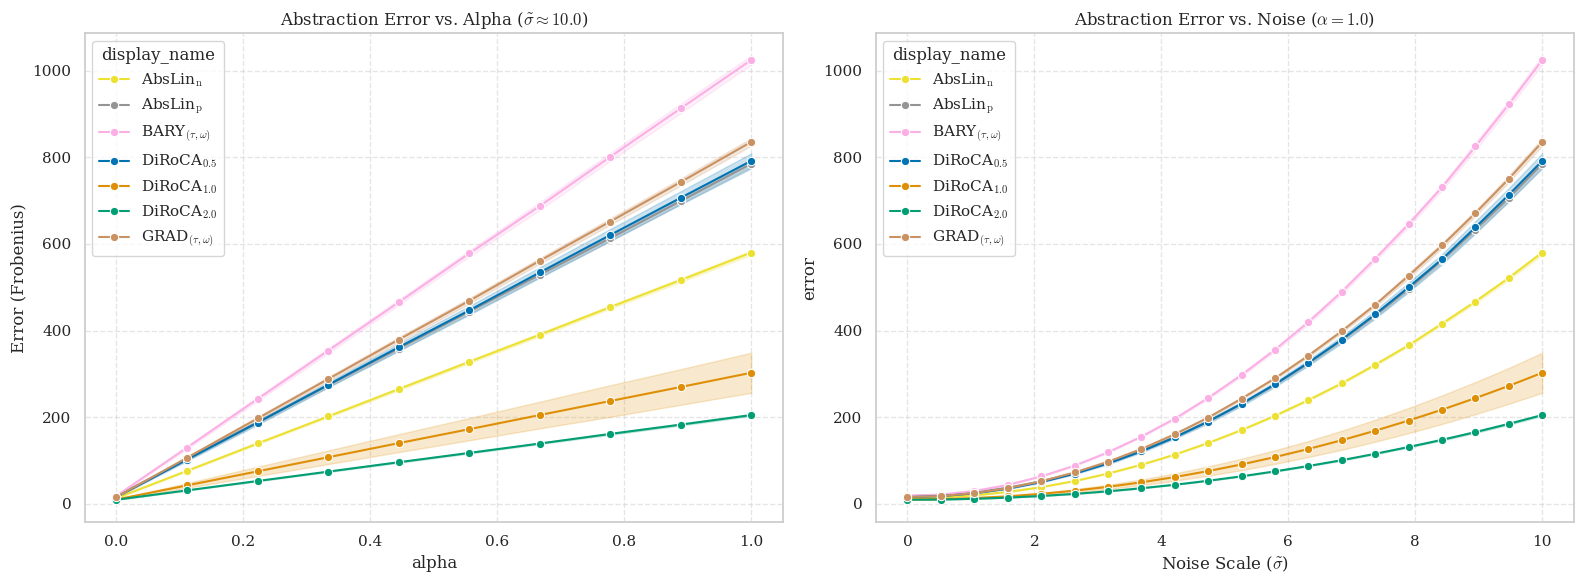


📊 Huber Stats (Sigma ≈ 10.00)

--- Alpha = 0.0 ---
                 Method  Mean Error    Std      Sig.
         DiRoCA$_{2.0}$      9.6665 0.1107 --- (Ref)
         DiRoCA$_{1.0}$     10.2707 0.5312       ***
    AbsLin$_{\text{n}}$     13.4886 0.4393       ***
         DiRoCA$_{0.5}$     15.8261 0.2352       ***
GRAD$_{(\tau, \omega)}$     15.8839 0.1278       ***
    AbsLin$_{\text{p}}$     18.2915 0.1592       ***
BARY$_{(\tau, \omega)}$     18.7384 0.1091       ***

--- Alpha = 1.0 ---
                 Method  Mean Error     Std      Sig.
         DiRoCA$_{2.0}$    205.0921  2.0911 --- (Ref)
         DiRoCA$_{1.0}$    302.7283 46.2893       ***
    AbsLin$_{\text{n}}$    580.0641  5.0912       ***
    AbsLin$_{\text{p}}$    785.2379  8.0131       ***
         DiRoCA$_{0.5}$    791.8040 17.3599       ***
GRAD$_{(\tau, \omega)}$    835.4501  8.5284       ***
BARY$_{(\tau, \omega)}$   1024.5429 10.2529       ***
🔄 Running Omega Test (K=11 swaps) on 4 files...


  0%|          | 0/20 [00:00<?, ?it/s]


📊 Omega Misspecification Stats (Maximal Corruption)
  > Most Robust Method: DiRoCA$_{2.0}$ (Error=5.28)
                 Method  Mean Error    Std      Sig.
         DiRoCA$_{2.0}$      5.2833 0.3349 --- (Ref)
         DiRoCA$_{1.0}$      5.6977 0.3437       ***
    AbsLin$_{\text{n}}$      6.6597 0.2660       ***
         DiRoCA$_{0.5}$      7.2812 0.2302       ***
GRAD$_{(\tau, \omega)}$      7.3041 0.2298       ***
    AbsLin$_{\text{p}}$      7.9003 0.2066       ***
BARY$_{(\tau, \omega)}$      7.9560 0.2098       ***


In [8]:
# --- 1. Settings ---
DISTRIBUTION = 'gaussian' # 'gaussian', 'student-t', 'exponential'
METHODS_TO_ANALYZE = [
    'DiRoCA_0.5', 'DiRoCA_1', 'DiRoCA_2', 
    'GradCA', 'BARYCA', 'Abslin_p', 'Abslin_n'
]

# --- 2. Load Results ---
df_res = load_lucas_results(DISTRIBUTION)

if df_res is not None:
    # --- 3. Run Plots ---
    # target_sigma=10.0 is the max noise in standard Lucas setup (adjust if you ran up to 5)
    run_plots(df_res, METHODS_TO_ANALYZE, target_sigma=10.0, target_alpha=1.0)
    
    # --- 4. Huber Stats Table ---
    generate_stats_table(df_res, METHODS_TO_ANALYZE, alpha_vals=[0.0, 1.0], target_sigma=10.0)

# --- 5. Omega Misspecification Analysis ---
if os.path.exists(PACK_PATH):
    omega_df = run_omega_misspecification(
        OMEGA, 
        RESULTS_DIR, 
        Dll_samples, 
        Dhl_samples, 
        num_trials=20
    )
    
    # Filter for methods of interest
    if not omega_df.empty:
        omega_df_filtered = omega_df[omega_df['method'].isin(METHODS_TO_ANALYZE)]
        generate_omega_stats(omega_df_filtered)

# NEW EVALUATION

In [1]:
import os
import glob
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

# --- Plotting Style ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "lines.linewidth": 2.5,
    "axes.titleweight": "bold"
})

# --- Paths ---
EXPERIMENT = "lucas"
BASE_DIR = f"data/{EXPERIMENT}"
PACK_PATH = os.path.join(BASE_DIR, "lucas_pack.pkl")
EVAL_DIR = os.path.join(BASE_DIR, "evaluation_results")

# --- Definitions ---
# Map raw CSV method names to internal IDs
LABEL_MAP_RAW = {
    'DiRoCA (eps_1.0_delta_1.0)': 'DiRoCA_1',
    'DiRoCA (eps_2.0_delta_2.0)': 'DiRoCA_2',
    'DiRoCA (eps_4.0_delta_4.0)': 'DiRoCA_4',
    'GradCA': 'GradCA',
    'gradca': 'GradCA',
    'BaryCA': 'BARYCA',
    'baryca': 'BARYCA',
    'Abs-LiNGAM (Perfect)': 'Abslin_p',
    'Abs-LiNGAM (Noisy)': 'Abslin_n'
}

# Map internal IDs to Publication Labels
PRINT_LABEL_MAP = {
    "DiRoCA_1"  : r"DiRoCA $(\epsilon=1)$",
    "DiRoCA_2"  : r"DiRoCA $(\epsilon=2)$",
    "GradCA"    : r"GradCA (ERM)",
    "BARYCA"    : r"BaryCA",
    "Abslin_p"  : r"Abs-LiNGAM (Perf)",
    "Abslin_n"  : r"Abs-LiNGAM (Noisy)"
}

# Consistent Colors
palette = sns.color_palette("colorblind")
COLOR_MAP = {
    r"DiRoCA $(\epsilon=1)$": palette[0], # Blue
    r"DiRoCA $(\epsilon=2)$": palette[9], # Light Blue
    r"GradCA (ERM)":          palette[3], # Red
    r"BaryCA":                palette[2], # Green
    r"Abs-LiNGAM (Perf)":     palette[7], # Grey
    r"Abs-LiNGAM (Noisy)":    palette[7]  # Grey
}

print(f"✅ Environment Ready. Looking for results in: {EVAL_DIR}")

✅ Environment Ready. Looking for results in: data/lucas/evaluation_results


In [2]:
def load_latest_results(distribution="gaussian", shift="additive"):
    """Finds and loads the most recent evaluation CSV for the given distribution."""
    # Pattern matches the filename format from your batch script
    pattern = f"empirical_evaluation_{shift}_{distribution}_*.csv"
    search_path = os.path.join(EVAL_DIR, pattern)
    
    # Sort by name (which includes timestamp) to get the newest
    files = sorted(glob.glob(search_path))
    
    if not files:
        print(f"❌ No files found for {distribution}. Check your evaluation_results folder.")
        return None
    
    latest_file = files[-1]
    print(f"📂 Loading: {os.path.basename(latest_file)}")
    
    try:
        df = pd.read_csv(latest_file)
        
        # Clean up Method Names
        df['method_raw'] = df['method']
        df['method'] = df['method'].map(lambda x: LABEL_MAP_RAW.get(x, x))
        
        # Add Display Names
        df['Display Name'] = df['method'].map(PRINT_LABEL_MAP)
        
        # Filter only methods we defined in the map
        df = df.dropna(subset=['Display Name'])
        
        print(f"✅ Loaded {len(df)} rows. Methods found: {df['method'].unique()}")
        return df
    except Exception as e:
        print(f"⚠️ Error reading file: {e}")
        return None

In [3]:
def plot_robustness_curves(df):
    """Generates the side-by-side robustness plots."""
    methods_order = [k for k in PRINT_LABEL_MAP.values() if k in df['Display Name'].unique()]
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # --- Plot A: Sensitivity to Distributional Shift (Alpha) ---
    # We fix noise scale to max (10.0) to see the full impact of shift
    max_noise = df['noise_scale'].max()
    df_shift = df[np.isclose(df['noise_scale'], max_noise)]
    
    sns.lineplot(
        data=df_shift, x='alpha', y='error', hue='Display Name', style='Display Name',
        palette=COLOR_MAP, hue_order=methods_order, style_order=methods_order,
        markers=True, dashes=False, linewidth=3, ax=axes[0]
    )
    axes[0].set_title(f"Sensitivity to Shift ($\\alpha$)\n(Fixed Noise $\sigma={max_noise}$)")
    axes[0].set_xlabel(r"Shift Strength ($\alpha$)")
    axes[0].set_ylabel("Abstraction Error (MSE)")
    axes[0].grid(True, alpha=0.3)
    axes[0].get_legend().remove()

    # --- Plot B: Sensitivity to Noise Magnitude (Sigma) ---
    # We fix alpha to 1.0 (Fully shifted distribution)
    df_noise = df[np.isclose(df['alpha'], 1.0)]
    
    sns.lineplot(
        data=df_noise, x='noise_scale', y='error', hue='Display Name', style='Display Name',
        palette=COLOR_MAP, hue_order=methods_order, style_order=methods_order,
        markers=True, dashes=False, linewidth=3, ax=axes[1]
    )
    axes[1].set_title(f"Sensitivity to Noise Magnitude ($\sigma$)\n(Fixed Shift $\\alpha=1.0$)")
    axes[1].set_xlabel(r"Noise Scale ($\sigma$)")
    axes[1].set_ylabel("") # Shared Y label often cleaner
    axes[1].grid(True, alpha=0.3)
    
    # Shared Legend
    handles, labels = axes[1].get_legend_handles_labels()
    axes[1].legend(handles=handles, labels=labels, title="Method", 
                   bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/var/folders/vn/9swzhgj513q7n9gd_4vsbd840000gn/T/ipykernel_40274/1485707602.py:17: SyntaxWarning: invalid escape sequence '\s'
  axes[0].set_title(f"Sensitivity to Shift ($\\alpha$)\n(Fixed Noise $\sigma={max_noise}$)")
/var/folders/vn/9swzhgj513q7n9gd_4vsbd840000gn/T/ipykernel_40274/1485707602.py:32: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set_title(f"Sensitivity to Noise Magnitude ($\sigma$)\n(Fixed Shift $\\alpha=1.0$)")


In [4]:
def print_comparison_table(df):
    """Prints the mean +/- std error for Clean (a=0) vs Noisy (a=1)."""
    
    # We look at two slices:
    # 1. Clean: Alpha=0 (Noise scale is irrelevant here, error should be const)
    # 2. Noisy: Alpha=1, Noise=Max (10.0)
    
    max_noise = df['noise_scale'].max()
    
    df_clean = df[np.isclose(df['alpha'], 0.0)]
    df_noisy = df[(np.isclose(df['alpha'], 1.0)) & (np.isclose(df['noise_scale'], max_noise))]
    
    print("\n" + "="*65)
    print(f"FINAL PERFORMANCE SUMMARY (LUCAS)")
    print("="*65)
    print(f"{'Method':<20} | {'Clean (α=0)':<18} | {'Shifted (α=1, σ=10)':<18}")
    print("-" * 65)
    
    methods = df['Display Name'].unique()
    # Sort to put GradCA and DiRoCA first
    methods = sorted(methods, key=lambda x: "Abs" in x) 
    
    for m in methods:
        # Clean Stats
        clean_scores = df_clean[df_clean['Display Name'] == m]['error']
        c_mean, c_std = clean_scores.mean(), clean_scores.std()
        
        # Noisy Stats
        noisy_scores = df_noisy[df_noisy['Display Name'] == m]['error']
        n_mean, n_std = noisy_scores.mean(), noisy_scores.std()
        
        print(f"{m:<20} | {c_mean:6.2f} +/- {c_std:4.2f}   | {n_mean:6.2f} +/- {n_std:4.2f}")
    
    print("="*65)

📂 Loading: empirical_evaluation_additive_gaussian_FINAL.csv
✅ Loaded 1200 rows. Methods found: ['GradCA' 'BARYCA' 'DiRoCA_1' 'DiRoCA_2' 'Abslin_p' 'Abslin_n']


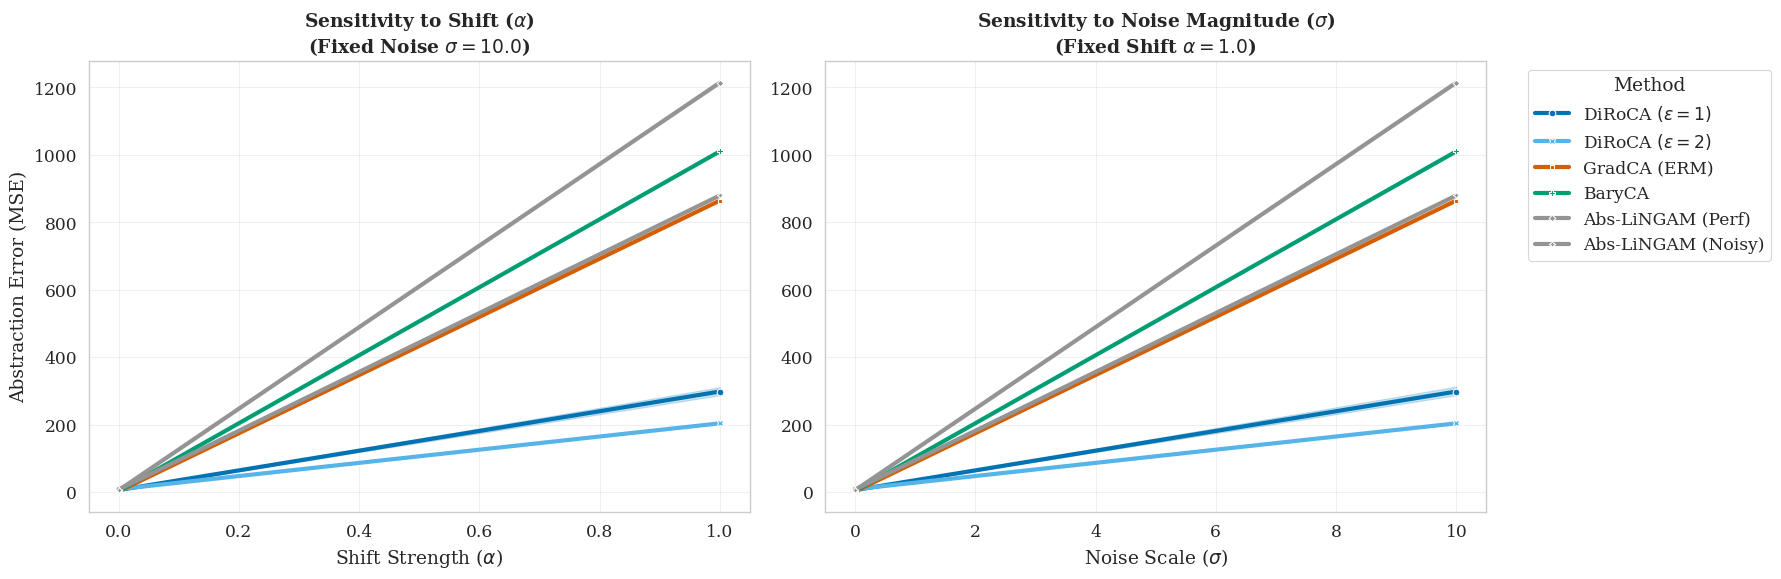


FINAL PERFORMANCE SUMMARY (LUCAS)
Method               | Clean (α=0)        | Shifted (α=1, σ=10)
-----------------------------------------------------------------
GradCA (ERM)         |   2.42 +/- 0.05   | 864.50 +/- 8.25
BaryCA               |   2.98 +/- 0.02   | 1010.36 +/- 7.62
DiRoCA $(\epsilon=1)$ |   6.35 +/- 0.92   | 298.48 +/- 44.22
DiRoCA $(\epsilon=2)$ |   8.90 +/- 0.23   | 204.20 +/- 2.09
Abs-LiNGAM (Perf)    |   5.94 +/- 0.04   | 1214.14 +/- 13.35
Abs-LiNGAM (Noisy)   |   7.93 +/- 0.07   | 879.67 +/- 8.70

🔍 SANITY CHECK: GradCA Clean Error is 2.4203
✅ SUCCESS: GradCA is optimized (Low clean error). Comparison is valid.


In [5]:
# 1. Load Data
df = load_latest_results(distribution="gaussian")

if df is not None:
    # 2. Generate Plots
    plot_robustness_curves(df)
    
    # 3. Generate Table
    print_comparison_table(df)
    
    # 4. Quick Check for the GradCA "Baseline" Issue
    grad_clean = df[(df['method'] == 'GradCA') & (np.isclose(df['alpha'], 0.0))]['error'].mean()
    print(f"\n🔍 SANITY CHECK: GradCA Clean Error is {grad_clean:.4f}")
    if grad_clean < 3.0:
        print("✅ SUCCESS: GradCA is optimized (Low clean error). Comparison is valid.")
    else:
        print("❌ WARNING: GradCA error is high (>3.0). It matches the unoptimized baseline.")
        print("   Action: Re-run optimization forcing --gradca-eta-min 0.01")

In [5]:
import os
import glob
import joblib
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from tqdm.auto import tqdm

# --- Configuration ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
plt.rcParams.update({
    "font.family": "serif",
    "axes.titleweight": "bold",
    "figure.titlesize": "large"
})

# Paths
EXPERIMENT = "lucas"
BASE_DIR = f"data/{EXPERIMENT}"
PACK_PATH = os.path.join(BASE_DIR, "lucas_pack.pkl")
RESULTS_DIR = os.path.join(BASE_DIR, "results_nonlinear")
EVAL_DIR = os.path.join(BASE_DIR, "evaluation_results")

# Mappings
PRINT_LABEL_MAP = {
    "DiRoCA (eps_1.0_delta_1.0)": r"DiRoCA $(\epsilon=1)$",
    "DiRoCA (eps_2.0_delta_2.0)": r"DiRoCA $(\epsilon=2)$",
    "DiRoCA (eps_4.0_delta_4.0)": r"DiRoCA $(\epsilon=4)$",
    "GradCA": r"GradCA (ERM)",
    "BaryCA": r"BaryCA",
    "Abs-LiNGAM (Perfect)": r"Abs-LiNGAM (Perf)",
    "Abs-LiNGAM (Noisy)": r"Abs-LiNGAM (Noisy)"
}

# Load Data Pack (Needed for Omega Tests)
if os.path.exists(PACK_PATH):
    pack = joblib.load(PACK_PATH)
    OMEGA = pack["omega"]
    # Reconstruct Observational Noise for Counterfactual Omega Tests
    iota0 = 'iota0'
    eta0 = OMEGA.get(iota0, 'eta0')
    if eta0 not in pack['hl']: eta0 = 'eta0'
    
    # Store deterministic parts D and observational noise U separately
    # This allows us to run the "Counterfactual" logic even in the omega test
    Dll_D = {k: pack["ll"][k]["D"] for k in pack["ll"]}
    Dhl_D = {k: pack["hl"][k]["D"] for k in pack["hl"]}
    U_ll_obs = pack["ll"][iota0]["U"]
    U_hl_obs = pack["hl"][eta0]["U"]
    
    print(f"✅ Data Pack Loaded. Omega size: {len(OMEGA)}")
else:
    print("⚠️ Pack not found.")
    OMEGA = {}

✅ Data Pack Loaded. Omega size: 11


In [6]:
def load_dual_mode_results(distribution="gaussian"):
    """Loads both standard and counterfactual CSVs."""
    dfs = {}
    for mode in ["standard", "counterfactual"]:
        pattern = f"{EVAL_DIR}/empirical_evaluation_*_{distribution}_mode_{mode}_*.csv"
        files = sorted(glob.glob(pattern), key=os.path.getmtime)
        
        if not files:
            print(f"⚠️ No file found for mode '{mode}'")
            continue
            
        latest = files[-1]
        print(f"📂 Loaded [{mode.upper()}]: {os.path.basename(latest)}")
        df = pd.read_csv(latest)
        df['Display Name'] = df['method'].map(PRINT_LABEL_MAP).fillna(df['method'])
        dfs[mode] = df
        
    return dfs

# Load Data
data_map = load_dual_mode_results("gaussian")

📂 Loaded [STANDARD]: empirical_evaluation_additive_gaussian_mode_standard_alpha10_noise20_trials20_20251212_195842.csv
📂 Loaded [COUNTERFACTUAL]: empirical_evaluation_additive_gaussian_mode_counterfactual_alpha10_noise20_trials20_20251212_201455.csv


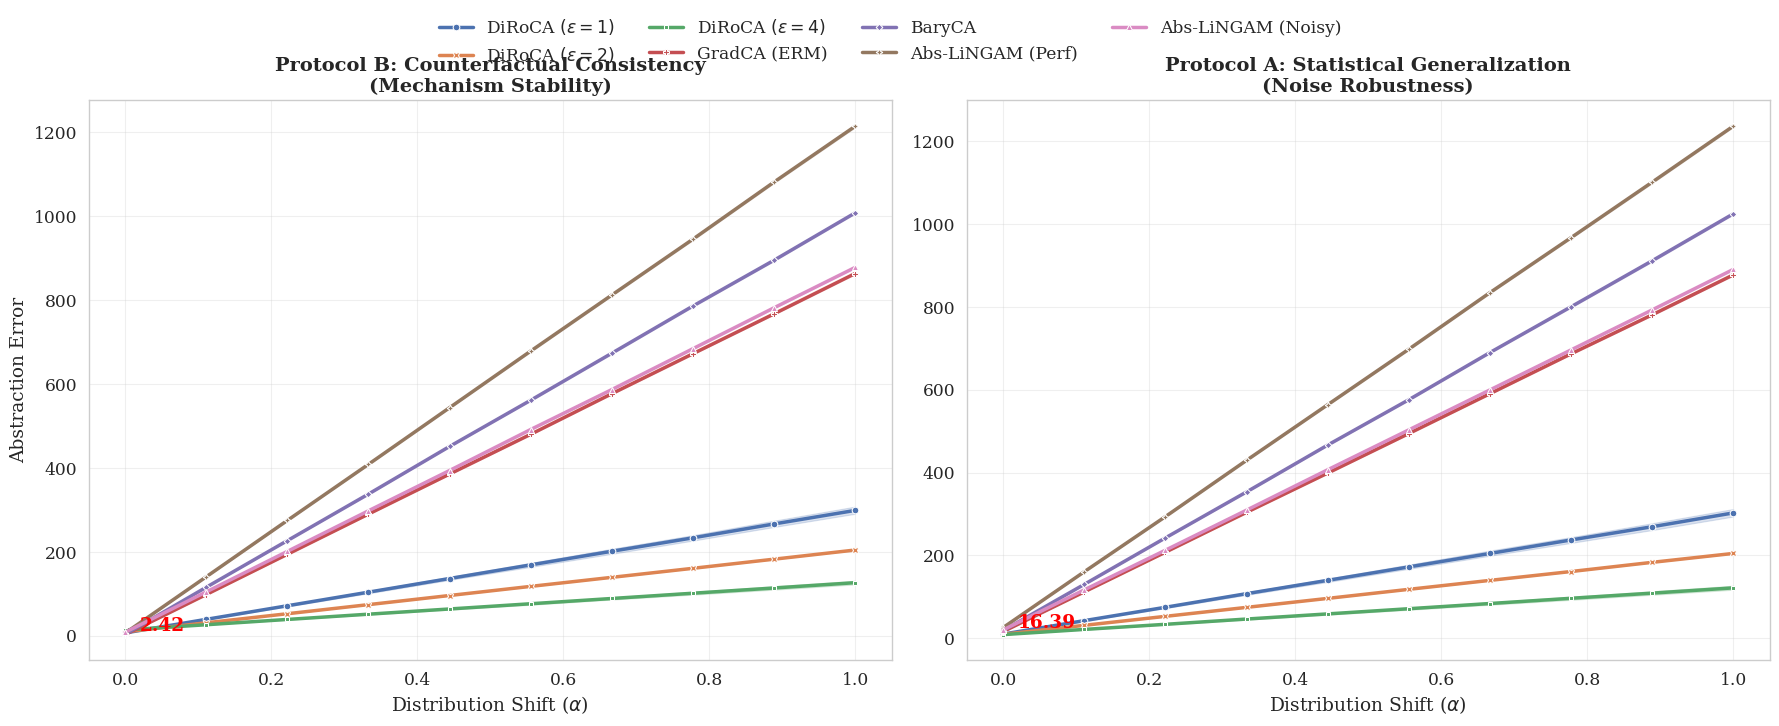

In [7]:
def plot_dual_robustness(data_map):
    if not data_map: return

    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)
    
    modes = [("counterfactual", "Protocol B: Counterfactual Consistency\n(Mechanism Stability)"),
             ("standard", "Protocol A: Statistical Generalization\n(Noise Robustness)")]
    
    # Get common legend order
    df_ref = list(data_map.values())[0]
    hue_order = sorted([m for m in PRINT_LABEL_MAP.values() if m in df_ref['Display Name'].unique()],
                       key=lambda x: "Abs" in x) # Put Baselines at end

    for i, (mode, title) in enumerate(modes):
        if mode not in data_map: continue
        df = data_map[mode]
        
        # Plot Error vs Alpha (at Max Noise)
        max_noise = df['noise_scale'].max()
        df_plot = df[np.isclose(df['noise_scale'], max_noise)]
        
        sns.lineplot(data=df_plot, x='alpha', y='error', hue='Display Name', style='Display Name',
                     hue_order=hue_order, style_order=hue_order,
                     markers=True, dashes=False, linewidth=2.5, ax=axes[i])
        
        axes[i].set_title(title, fontsize=14, fontweight='bold')
        axes[i].set_xlabel(r"Distribution Shift ($\alpha$)")
        axes[i].set_ylabel("Abstraction Error" if i==0 else "")
        axes[i].grid(True, alpha=0.3)
        
        # Annotate Clean Error for GradCA
        grad_err = df_plot[(df_plot['Display Name'].str.contains("Grad")) & (df_plot['alpha']==0)]['error'].mean()
        axes[i].text(0.02, grad_err, f"{grad_err:.2f}", color='red', fontweight='bold', ha='left', va='bottom')

    # Single Legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4, frameon=False)
    axes[0].get_legend().remove()
    axes[1].get_legend().remove()
    
    plt.tight_layout()
    plt.show()

plot_dual_robustness(data_map)

In [8]:
def run_omega_misspecification(omega_map, results_dir, dll_D, dhl_D, U_ll, U_hl, num_trials=10):
    """
    Re-evaluates trained models using a CORRUPTED omega map.
    Uses Counterfactual Reconstruction (D + U_obs) to isolate structural error.
    """
    # 1. Load CV Folds indices from any result file
    ref_pkl = glob.glob(os.path.join(results_dir, "*_cv_results_empirical.pkl"))[0]
    loaded_ref = joblib.load(ref_pkl)
    
    saved_folds = []
    # Handle nested structure to find test indices
    first_fold_key = next(iter(loaded_ref.keys()))
    if "test_indices" in loaded_ref[first_fold_key]: # Flat structure
        for k, v in loaded_ref.items():
            if "fold_" in k: saved_folds.append({"id": int(k.split("_")[1]), "test": v["test_indices"]})
    else: # Nested structure (DiRoCA/AbsLin)
        first_run_key = next(iter(loaded_ref[first_fold_key].keys()))
        for k, v in loaded_ref.items():
            if "fold_" in k:
                saved_folds.append({"id": int(k.split("_")[1]), "test": v[first_run_key]["test_indices"]})

    # 2. Run Corruption Tests
    pkl_files = glob.glob(os.path.join(results_dir, "*_cv_results_empirical.pkl"))
    records = []
    K_corruption = len(omega_map)
    
    print(f"🔄 Running Omega Test (K={K_corruption} swaps) on {len(pkl_files)} models...")

    for trial in tqdm(range(num_trials), desc="Trials"):
        # -- Generate Corrupt Map --
        corrupt_omega = omega_map.copy()
        ll_keys = list(omega_map.keys())
        hl_targets = list(omega_map.values())
        random.shuffle(ll_keys) # Shuffle keys to force mismatch
        for i, ll_node in enumerate(ll_keys):
            corrupt_omega[ll_node] = hl_targets[i] # Assign shuffled target

        # -- Evaluate All Models --
        for pkl_path in pkl_files:
            base_name = os.path.basename(pkl_path).replace("_cv_results_empirical.pkl", "")
            data = joblib.load(pkl_path)
            
            for fold in saved_folds:
                fold_key = f"fold_{fold['id']}"
                if fold_key not in data: continue
                
                # Iterate over runs within fold (handles both flat and nested)
                fold_content = data[fold_key]
                if "T_matrix" in fold_content: # Flat (GradCA/BaryCA)
                    runs = {base_name: fold_content}
                else: # Nested (DiRoCA/AbsLin)
                    runs = fold_content

                test_idx = fold["test"]
                
                for run_id, res in runs.items():
                    T = res.get("T_matrix", res.get("T"))
                    if T is None: continue
                    
                    # Compute Error on CORRUPT Mapping
                    errors = []
                    for ll_node in omega_map.keys(): # Iterate through true LL interventions
                        # We project LL -> HL using the WRONG map
                        target_hl_wrong = corrupt_omega[ll_node]
                        
                        if ll_node not in dll_D or target_hl_wrong not in dhl_D: continue

                        # METHOD B: Counterfactual Reconstruction
                        # X_eval = D_intervention + U_observational
                        X_ll = dll_D[ll_node][test_idx] + U_ll[test_idx]
                        X_hl = dhl_D[target_hl_wrong][test_idx] + U_hl[test_idx] # The "Wrong" target
                        
                        # Apply T projection
                        X_pred = X_ll @ T.T
                        err = np.linalg.norm(X_pred - X_hl, ord='fro')**2 / (X_pred.shape[0]*X_pred.shape[1])
                        errors.append(err)
                    
                    if not errors: continue

                    # Name Cleaning for Plotting
                    clean_name = "Unknown"
                    if "gradca" in base_name: clean_name = "GradCA"
                    elif "baryca" in base_name: clean_name = "BaryCA"
                    elif "diroca" in base_name: clean_name = f"DiRoCA_{run_id}"
                    elif "abslin" in base_name: clean_name = f"AbsLin_{run_id}"
                    
                    # Normalize DiRoCA names
                    if "eps_" in str(run_id):
                        eps = run_id.split('_')[1]
                        clean_name = f"DiRoCA (eps={eps})"

                    records.append({
                        "method": clean_name,
                        "fold": fold['id'],
                        "trial": trial,
                        "error": np.mean(errors)
                    })
                    
    return pd.DataFrame(records)

def generate_omega_stats(df):
    if df.empty: return
    print("\n📊 Omega Misspecification Stats (How robust are maps to wrong targets?)")
    
    pivot = df.pivot_table(index=['fold', 'trial'], columns='method', values='error')
    results = []
    
    # Identify Robust Winner (Lowest Error under Corruption)
    mean_errs = pivot.mean()
    best_method = mean_errs.idxmin()
    print(f"  > Most Robust to Misspecification: {best_method} (Err={mean_errs[best_method]:.2f})")
    
    ref_scores = pivot[best_method]
    
    for m in pivot.columns:
        scores = pivot[m]
        sig = ""
        if m != best_method:
            # Paired t-test
            _, p = ttest_rel(ref_scores, scores)
            if p < 0.001: sig = "***"
            elif p < 0.01: sig = "**"
            elif p < 0.05: sig = "*"
            
        results.append({
            "Method": m,
            "Error (Corrupt)": scores.mean(),
            "Std": scores.std(),
            "Sig.": sig
        })
        
    print(pd.DataFrame(results).sort_values("Error (Corrupt)").to_string(index=False, float_format="%.2f"))

# Execution
if os.path.exists(PACK_PATH):
    df_omega = run_omega_misspecification(
        OMEGA, RESULTS_DIR, Dll_D, Dhl_D, U_ll_obs, U_hl_obs, num_trials=10
    )
    generate_omega_stats(df_omega)

🔄 Running Omega Test (K=11 swaps) on 4 models...


Trials:   0%|          | 0/10 [00:00<?, ?it/s]


📊 Omega Misspecification Stats (How robust are maps to wrong targets?)
  > Most Robust to Misspecification: GradCA (Err=2.95)
          Method  Error (Corrupt)  Std Sig.
          GradCA             2.95 0.15     
DiRoCA (eps=0.5)             3.04 0.14  ***
          BaryCA             3.55 0.19  ***
  AbsLin_Perfect             6.60 0.22  ***
DiRoCA (eps=1.0)             6.65 0.89  ***
    AbsLin_Noisy             8.29 0.21  ***
DiRoCA (eps=2.0)             9.03 0.26  ***
DiRoCA (eps=4.0)            13.52 2.24  ***
DiRoCA (eps=8.0)            13.52 2.24  ***


In [9]:
def print_final_comparison(data_map):
    if not data_map: return
    
    df_std = data_map.get("standard")
    df_cf = data_map.get("counterfactual")
    
    print("\n" + "="*90)
    print(f"FINAL PAPER TABLE: Divergence of Evaluation Protocols")
    print("="*90)
    print(f"{'Method':<25} | {'Protocol B (Mech.)':<20} | {'Protocol A (Gen.)':<20} | {'Shifted (Robustness)':<20}")
    print(f"{'':<25} | {'α=0 (Consistency)':<20} | {'α=0 (Real World)':<20} | {'α=1 (Worst Case)':<20}")
    print("-" * 90)
    
    methods = sorted(df_std['Display Name'].unique(), key=lambda x: "Abs" in x)
    
    for m in methods:
        # 1. Consistency (Protocol B, Alpha=0)
        err_mech = df_cf[(df_cf['Display Name'] == m) & (df_cf['alpha'] == 0)]['error'].mean()
        
        # 2. Generalization (Protocol A, Alpha=0)
        err_gen  = df_std[(df_std['Display Name'] == m) & (df_std['alpha'] == 0)]['error'].mean()
        
        # 3. Robustness (Protocol A, Alpha=1, Max Noise)
        max_noise = df_std['noise_scale'].max()
        err_rob  = df_std[(df_std['Display Name'] == m) & (df_std['alpha'] == 1) & (np.isclose(df_std['noise_scale'], max_noise))]['error'].mean()
        
        print(f"{m:<25} | {err_mech:<20.2f} | {err_gen:<20.2f} | {err_rob:<20.2f}")
    print("="*90)

print_final_comparison(data_map)


FINAL PAPER TABLE: Divergence of Evaluation Protocols
Method                    | Protocol B (Mech.)   | Protocol A (Gen.)    | Shifted (Robustness)
                          | α=0 (Consistency)    | α=0 (Real World)     | α=1 (Worst Case)    
------------------------------------------------------------------------------------------
GradCA (ERM)              | 2.42                 | 16.39                | 877.08              
BaryCA                    | 2.98                 | 18.74                | 1024.33             
DiRoCA (eps_0.5_delta_0.5) | 2.52                 | 15.83                | 792.04              
DiRoCA $(\epsilon=1)$     | 6.35                 | 10.27                | 302.58              
DiRoCA $(\epsilon=2)$     | 8.90                 | 9.67                 | 204.86              
DiRoCA $(\epsilon=4)$     | 13.48                | 8.98                 | 121.69              
DiRoCA (eps_8.0_delta_8.0) | 13.49                | 8.98                 | 121.61            

In [10]:
def run_omega_misspecification_dual(omega_map, results_dir, pack, num_trials=10):
    """
    Runs Omega Misspecification in BOTH Standard (A) and Counterfactual (B) modes.
    """
    # 1. Load CV Folds indices
    ref_pkl = glob.glob(os.path.join(results_dir, "*_cv_results_empirical.pkl"))[0]
    loaded_ref = joblib.load(ref_pkl)
    
    saved_folds = []
    first_fold_key = next(iter(loaded_ref.keys()))
    if "test_indices" in loaded_ref[first_fold_key]: 
        for k, v in loaded_ref.items():
            if "fold_" in k: saved_folds.append({"id": int(k.split("_")[1]), "test": v["test_indices"]})
    else: 
        first_run_key = next(iter(loaded_ref[first_fold_key].keys()))
        for k, v in loaded_ref.items():
            if "fold_" in k:
                saved_folds.append({"id": int(k.split("_")[1]), "test": v[first_run_key]["test_indices"]})

    # Prepare Shared Noise for Mode B
    iota0 = 'iota0'
    eta0 = omega_map.get(iota0, 'eta0')
    U_ll_obs = pack["ll"][iota0]["U"]
    U_hl_obs = pack["hl"][eta0]["U"]

    pkl_files = glob.glob(os.path.join(results_dir, "*_cv_results_empirical.pkl"))
    records = []
    
    print(f"🔄 Running Dual-Mode Omega Test...")

    for mode in ["standard", "counterfactual"]:
        print(f"   > Mode: {mode.upper()}")
        
        for trial in tqdm(range(num_trials), desc=f"Trials ({mode})"):
            # Corrupt the Map
            corrupt_omega = omega_map.copy()
            ll_keys = list(omega_map.keys())
            hl_targets = list(omega_map.values())
            random.shuffle(ll_keys)
            for i, ll_node in enumerate(ll_keys):
                corrupt_omega[ll_node] = hl_targets[i]

            for pkl_path in pkl_files:
                base_name = os.path.basename(pkl_path).replace("_cv_results_empirical.pkl", "")
                data = joblib.load(pkl_path)
                
                for fold in saved_folds:
                    fold_key = f"fold_{fold['id']}"
                    if fold_key not in data: continue
                    fold_content = data[fold_key]
                    runs = {base_name: fold_content} if "T_matrix" in fold_content else fold_content
                    test_idx = fold["test"]
                    
                    for run_id, res in runs.items():
                        T = res.get("T_matrix", res.get("T"))
                        if T is None: continue
                        
                        errors = []
                        for ll_node in omega_map.keys():
                            target_hl_wrong = corrupt_omega[ll_node]
                            if ll_node not in pack["ll"] or target_hl_wrong not in pack["hl"]: continue

                            # --- DATA SELECTION LOGIC ---
                            if mode == "standard":
                                # Protocol A: Raw Samples (Generalization)
                                X_ll = pack["ll"][ll_node]["X"][test_idx]
                                X_hl = pack["hl"][target_hl_wrong]["X"][test_idx]
                            else:
                                # Protocol B: Reconstructed (Consistency)
                                D_L = pack["ll"][ll_node]["D"][test_idx]
                                D_H = pack["hl"][target_hl_wrong]["D"][test_idx]
                                X_ll = D_L + U_ll_obs[test_idx]
                                X_hl = D_H + U_hl_obs[test_idx]
                            # ----------------------------
                            
                            X_pred = X_ll @ T.T
                            err = np.linalg.norm(X_pred - X_hl, ord='fro')**2 / (X_pred.shape[0]*X_pred.shape[1])
                            errors.append(err)
                        
                        if not errors: continue

                        # Naming
                        clean_name = "Unknown"
                        if "gradca" in base_name: clean_name = "GradCA"
                        elif "baryca" in base_name: clean_name = "BaryCA"
                        elif "diroca" in base_name: 
                            if "eps_" in str(run_id):
                                eps = run_id.split('_')[1]
                                clean_name = f"DiRoCA (eps={eps})"
                            else: clean_name = f"DiRoCA_{run_id}"
                        elif "abslin" in base_name: clean_name = f"AbsLin_{run_id}"

                        records.append({
                            "mode": mode,
                            "method": clean_name,
                            "fold": fold['id'],
                            "trial": trial,
                            "error": np.mean(errors)
                        })
                        
    return pd.DataFrame(records)

def generate_dual_omega_stats(df):
    if df.empty: return
    
    for mode in ["standard", "counterfactual"]:
        print(f"\n📊 Omega Stats: [{mode.upper()}]")
        sub = df[df['mode'] == mode]
        
        pivot = sub.pivot_table(index=['fold', 'trial'], columns='method', values='error')
        results = []
        
        mean_errs = pivot.mean()
        best_method = mean_errs.idxmin()
        print(f"  > Winner: {best_method} (Err={mean_errs[best_method]:.2f})")
        
        ref_scores = pivot[best_method]
        for m in pivot.columns:
            scores = pivot[m]
            sig = ""
            if m != best_method:
                _, p = ttest_rel(ref_scores, scores)
                if p < 0.001: sig = "***"
                elif p < 0.01: sig = "**"
                elif p < 0.05: sig = "*"
            
            results.append({"Method": m, "Error": scores.mean(), "Sig": sig})
            
        print(pd.DataFrame(results).sort_values("Error").to_string(index=False, float_format="%.2f"))

# Run it
if os.path.exists(PACK_PATH):
    df_omega_dual = run_omega_misspecification_dual(OMEGA, RESULTS_DIR, pack, num_trials=10)
    generate_dual_omega_stats(df_omega_dual)

🔄 Running Dual-Mode Omega Test...
   > Mode: STANDARD


Trials (standard):   0%|          | 0/10 [00:00<?, ?it/s]

   > Mode: COUNTERFACTUAL


Trials (counterfactual):   0%|          | 0/10 [00:00<?, ?it/s]


📊 Omega Stats: [STANDARD]
  > Winner: DiRoCA (eps=8.0) (Err=9.16)
          Method  Error Sig
DiRoCA (eps=8.0)   9.16    
DiRoCA (eps=4.0)   9.16 ***
DiRoCA (eps=2.0)  10.28 ***
DiRoCA (eps=1.0)  11.74 ***
DiRoCA (eps=0.5)  18.50 ***
          GradCA  19.16 ***
          BaryCA  21.96 ***
    AbsLin_Noisy  23.22 ***
  AbsLin_Perfect  29.99 ***

📊 Omega Stats: [COUNTERFACTUAL]
  > Winner: GradCA (Err=3.05)
          Method  Error Sig
          GradCA   3.05    
DiRoCA (eps=0.5)   3.13 ***
          BaryCA   3.69 ***
DiRoCA (eps=1.0)   6.68 ***
  AbsLin_Perfect   6.78 ***
    AbsLin_Noisy   8.44 ***
DiRoCA (eps=2.0)   9.04 ***
DiRoCA (eps=4.0)  13.52 ***
DiRoCA (eps=8.0)  13.52 ***


In [11]:
import os
import glob

EVAL_DIR = "data/lucas/evaluation_results"
modes = ["standard", "counterfactual"]
dists = ["gaussian", "student-t", "exponential"]

print(f"Checking data in: {EVAL_DIR}\n")

found_all = True
for dist in dists:
    print(f"--- {dist.upper()} ---")
    for mode in modes:
        pattern = f"{EVAL_DIR}/empirical_evaluation_*_{dist}_mode_{mode}_*.csv"
        files = glob.glob(pattern)
        if files:
            latest = sorted(files, key=os.path.getmtime)[-1]
            print(f"  ✅ {mode:<15}: {os.path.basename(latest)}")
        else:
            print(f"  ❌ {mode:<15}: MISSING")
            found_all = False

if found_all:
    print("\n🎉 ALL DATASETS READY FOR PLOTTING.")
else:
    print("\n⚠️ SOME FILES ARE MISSING.")

Checking data in: data/lucas/evaluation_results

--- GAUSSIAN ---
  ✅ standard       : empirical_evaluation_additive_gaussian_mode_standard_alpha10_noise20_trials20_20251212_205424.csv
  ✅ counterfactual : empirical_evaluation_additive_gaussian_mode_counterfactual_alpha10_noise20_trials20_20251212_211555.csv
--- STUDENT-T ---
  ✅ standard       : empirical_evaluation_additive_student-t_mode_standard_alpha10_noise20_trials20_20251212_213418.csv
  ✅ counterfactual : empirical_evaluation_additive_student-t_mode_counterfactual_alpha10_noise20_trials20_20251212_215348.csv
--- EXPONENTIAL ---
  ✅ standard       : empirical_evaluation_additive_exponential_mode_standard_alpha10_noise20_trials20_20251212_220343.csv
  ✅ counterfactual : empirical_evaluation_additive_exponential_mode_counterfactual_alpha10_noise20_trials20_20251212_221516.csv

🎉 ALL DATASETS READY FOR PLOTTING.


Generating Main Figure (Gaussian)...
Saved plot to lucas_gaussian_divergence.pdf


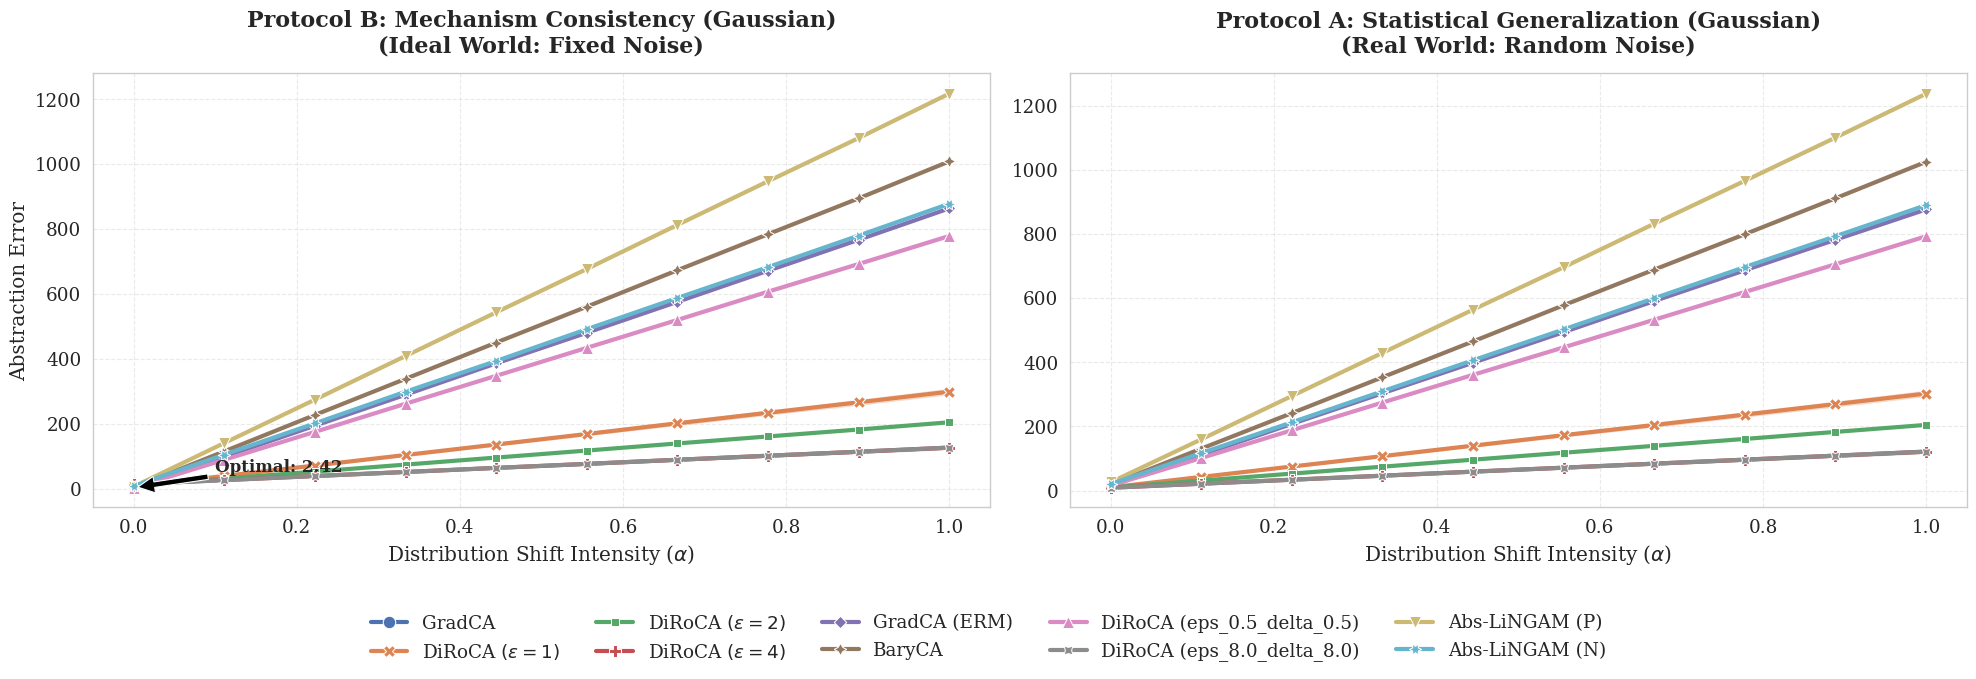


Generating Appendix Figure (Student-t)...
Saved plot to lucas_studentt_divergence.pdf


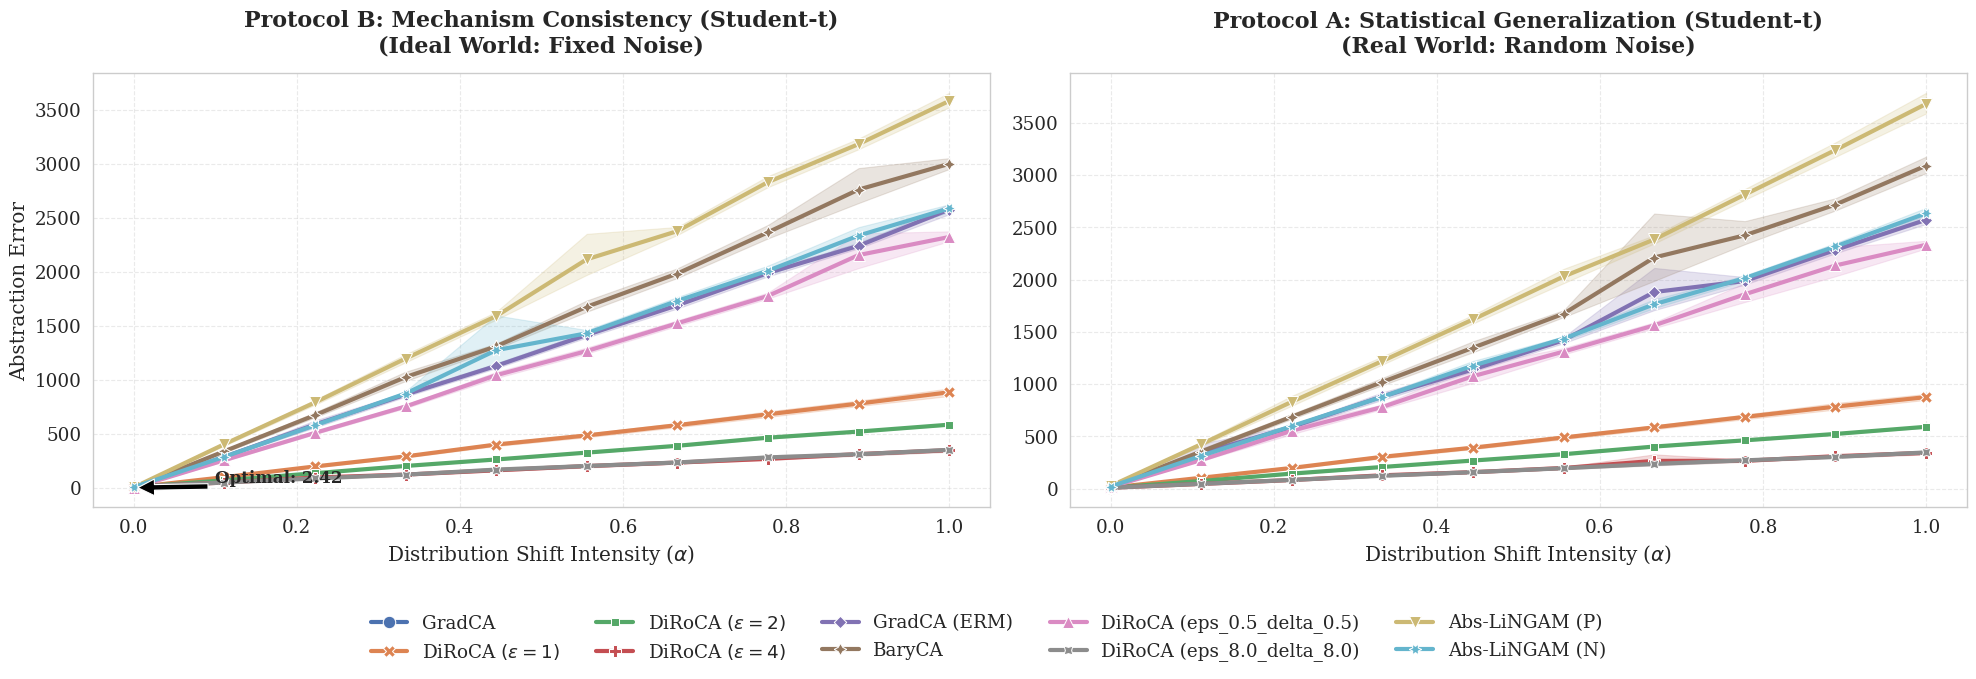


Generating Appendix Figure (Exponential)...
Saved plot to lucas_exponential_divergence.pdf


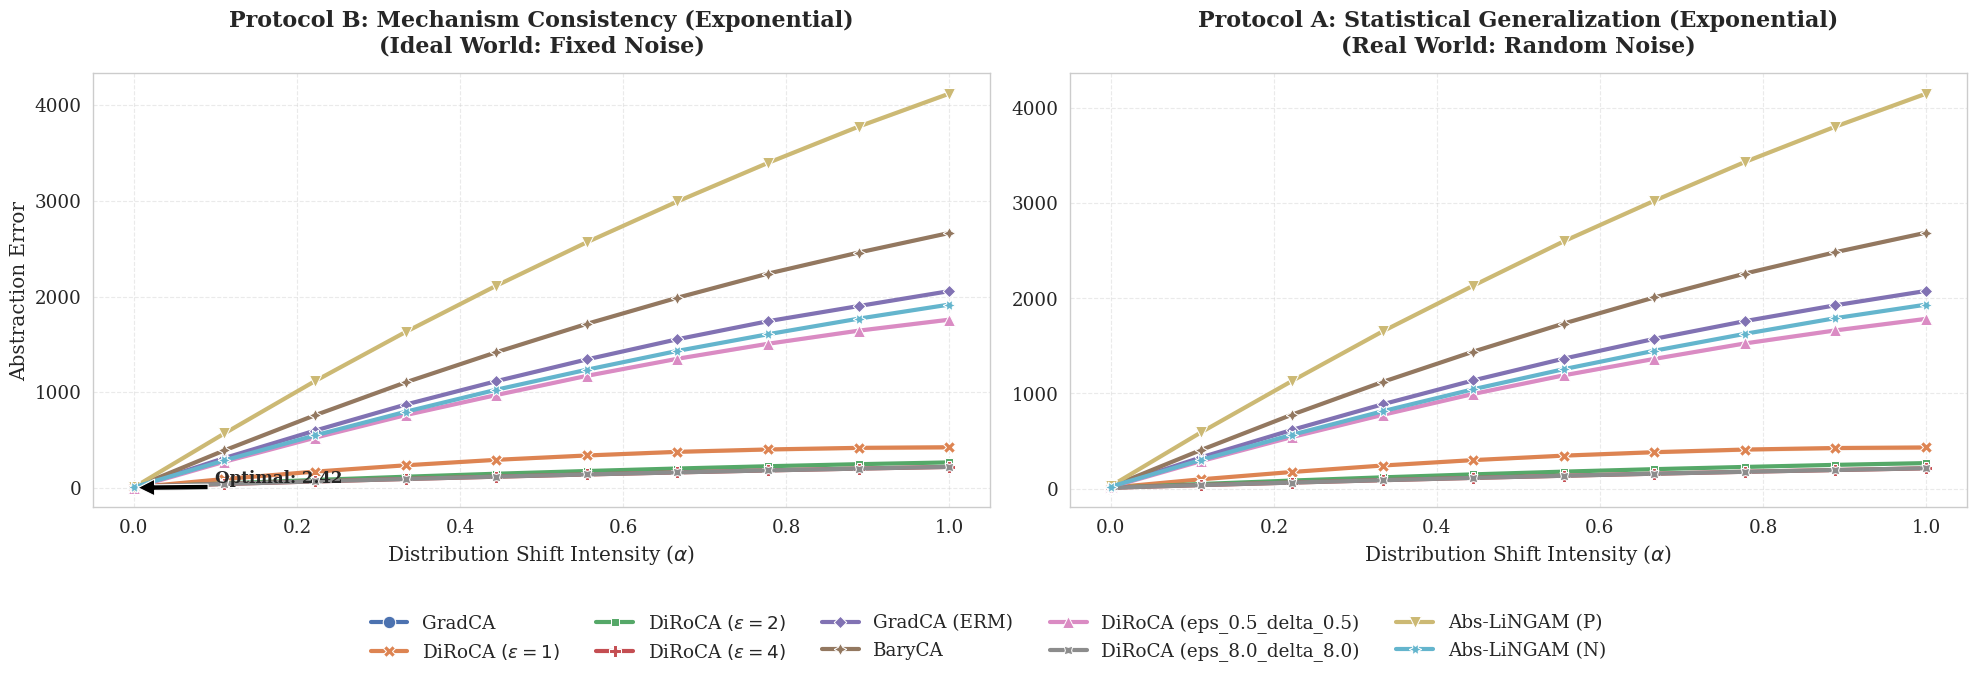

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

# Configuration
sns.set_theme(style="whitegrid", context="paper", font_scale=1.5)
plt.rcParams.update({'font.family': 'serif', 'axes.titleweight': 'bold'})

PRINT_LABEL_MAP = {
    "DiRoCA (eps_1.0_delta_1.0)": r"DiRoCA $(\epsilon=1)$",
    "DiRoCA (eps_2.0_delta_2.0)": r"DiRoCA $(\epsilon=2)$",
    "DiRoCA (eps_4.0_delta_4.0)": r"DiRoCA $(\epsilon=4)$",
    "GradCA": r"GradCA (ERM)",
    "BaryCA": r"BaryCA",
    "Abs-LiNGAM (Perfect)": r"Abs-LiNGAM (P)",
    "Abs-LiNGAM (Noisy)": r"Abs-LiNGAM (N)"
}

def plot_paper_figure(distribution="gaussian", save_path=None):
    """
    Generates the side-by-side Protocol A vs Protocol B plot for a specific distribution.
    """
    # Load Data
    dfs = {}
    for mode in ["counterfactual", "standard"]:
        pattern = f"data/lucas/evaluation_results/empirical_evaluation_*_{distribution}_mode_{mode}_*.csv"
        files = sorted(glob.glob(pattern), key=os.path.getmtime)
        if not files:
            print(f"Skipping {distribution} {mode} (not found)"); return
        df = pd.read_csv(files[-1])
        df['Display Name'] = df['method'].map(PRINT_LABEL_MAP).fillna(df['method'])
        dfs[mode] = df

    # Setup Plot
    fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=False)
    
    # Define Legend Order (GradCA first, then DiRoCA, then others)
    ref_df = dfs["standard"]
    hue_order = ["GradCA"] + [m for m in PRINT_LABEL_MAP.values() if "DiRoCA" in m and m in ref_df['Display Name'].unique()]
    hue_order += [m for m in ref_df['Display Name'].unique() if m not in hue_order]

    titles = [
        f"Protocol B: Mechanism Consistency ({distribution.capitalize()})\n(Ideal World: Fixed Noise)",
        f"Protocol A: Statistical Generalization ({distribution.capitalize()})\n(Real World: Random Noise)"
    ]

    for i, (mode, title) in enumerate(zip(["counterfactual", "standard"], titles)):
        df = dfs[mode]
        # Filter for Maximum Noise Scale (Worst-case noise magnitude)
        max_noise = df['noise_scale'].max()
        df_plot = df[np.isclose(df['noise_scale'], max_noise)]
        
        sns.lineplot(
            data=df_plot, x='alpha', y='error', 
            hue='Display Name', style='Display Name',
            hue_order=hue_order, style_order=hue_order,
            markers=True, dashes=False, linewidth=3, markersize=9, ax=axes[i]
        )
        
        axes[i].set_title(title, fontsize=16, pad=15)
        axes[i].set_xlabel(r"Distribution Shift Intensity ($\alpha$)")
        axes[i].set_ylabel("Abstraction Error" if i==0 else "")
        axes[i].grid(True, alpha=0.4, linestyle='--')
        
        # Highlight the divergence at Alpha=0
        if i == 0: # Counterfactual
            grad_err = df_plot[(df_plot['Display Name'].str.contains("Grad")) & (df_plot['alpha']==0)]['error'].mean()
            axes[i].annotate(f"Optimal: {grad_err:.2f}", xy=(0, grad_err), xytext=(0.1, grad_err+50),
                             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12, fontweight='bold')

    # Unified Legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=5, frameon=False)
    axes[0].get_legend().remove()
    axes[1].get_legend().remove()
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Saved plot to {save_path}")
    plt.show()

# --- GENERATE PLOTS ---
print("Generating Main Figure (Gaussian)...")
plot_paper_figure("gaussian", "lucas_gaussian_divergence.pdf")

print("\nGenerating Appendix Figure (Student-t)...")
plot_paper_figure("student-t", "lucas_studentt_divergence.pdf")

print("\nGenerating Appendix Figure (Exponential)...")
plot_paper_figure("exponential", "lucas_exponential_divergence.pdf")

In [13]:
import pandas as pd
import numpy as np
import glob
import os
import joblib
import random
from scipy.stats import ttest_rel
from tqdm.auto import tqdm

# --- Configuration ---
EXPERIMENT = "lucas"
BASE_DIR = f"data/{EXPERIMENT}"
EVAL_DIR = os.path.join(BASE_DIR, "evaluation_results")
PACK_PATH = os.path.join(BASE_DIR, "lucas_pack.pkl")
RESULTS_DIR = os.path.join(BASE_DIR, "results_nonlinear")

PRINT_LABEL_MAP = {
    "DiRoCA (eps_1.0_delta_1.0)": r"DiRoCA (e=1)",
    "DiRoCA (eps_2.0_delta_2.0)": r"DiRoCA (e=2)",
    "DiRoCA (eps_4.0_delta_4.0)": r"DiRoCA (e=4)",
    "DiRoCA (eps_8.0_delta_8.0)": r"DiRoCA (e=8)",
    "GradCA": r"GradCA",
    "BaryCA": r"BaryCA",
    "Abs-LiNGAM (Perfect)": r"AbsLin (P)",
    "Abs-LiNGAM (Noisy)": r"AbsLin (N)"
}

# --- 1. Huber Analysis (Alpha 0 vs 1) ---
def get_huber_table_data(distribution="gaussian"):
    print(f"\ngenerating Huber Table Data ({distribution})...")
    
    results = {}
    
    for mode in ["counterfactual", "standard"]:
        # Find latest file
        pattern = f"{EVAL_DIR}/empirical_evaluation_*_{distribution}_mode_{mode}_*.csv"
        files = sorted(glob.glob(pattern), key=os.path.getmtime)
        if not files: 
            print(f"⚠️ Missing file for {mode}"); continue
            
        df = pd.read_csv(files[-1])
        df['Method'] = df['method'].map(PRINT_LABEL_MAP).fillna(df['method'])
        
        # Filter: Max Noise Scale (Worst Case for Alpha=1)
        max_noise = df['noise_scale'].max()
        df = df[np.isclose(df['noise_scale'], max_noise)]
        
        # Group by Method and Alpha
        stats = df.groupby(['Method', 'alpha'])['error'].agg(['mean', 'std']).reset_index()
        
        # Extract Alpha=0 and Alpha=1
        for m in stats['Method'].unique():
            row_0 = stats[(stats['Method'] == m) & (stats['alpha'] == 0)]
            row_1 = stats[(stats['Method'] == m) & (stats['alpha'] == 1)]
            
            if not row_0.empty and not row_1.empty:
                val_0 = f"{row_0['mean'].values[0]:.2f} ± {row_0['std'].values[0]:.2f}"
                val_1 = f"{row_1['mean'].values[0]:.2f} ± {row_1['std'].values[0]:.2f}"
                
                if m not in results: results[m] = {}
                results[m][f"{mode}_a0"] = val_0
                results[m][f"{mode}_a1"] = val_1

    # Print Table
    print("\n" + "="*80)
    print(f"TABLE 1: HUBER ROBUSTNESS ({distribution.upper()})")
    print(f"{'Method':<20} | {'Mech (A=0)':<18} | {'Mech (A=1)':<18} | {'Gen (A=0)':<18} | {'Gen (A=1)':<18}")
    print("-" * 80)
    
    # Sort for consistent display
    sorted_keys = sorted(results.keys(), key=lambda x: "Abs" in x)
    
    for m in sorted_keys:
        r = results[m]
        print(f"{m:<20} | {r.get('counterfactual_a0', '-'):<18} | {r.get('counterfactual_a1', '-'):<18} | {r.get('standard_a0', '-'):<18} | {r.get('standard_a1', '-'):<18}")
    print("="*80 + "\n")

# --- 2. Omega Misspecification (Dual Mode) ---
def run_omega_analysis():
    # Load Pack
    if not os.path.exists(PACK_PATH): return
    pack = joblib.load(PACK_PATH)
    omega_map = pack["omega"]
    
    # Prepare Shared Noise
    iota0 = 'iota0'
    eta0 = omega_map.get(iota0, 'eta0')
    if eta0 not in pack['hl']: eta0 = 'eta0'
    U_ll_obs = pack["ll"][iota0]["U"]
    U_hl_obs = pack["hl"][eta0]["U"]
    
    # Load Indices
    ref_pkl = glob.glob(os.path.join(RESULTS_DIR, "*_cv_results_empirical.pkl"))[0]
    loaded_ref = joblib.load(ref_pkl)
    saved_folds = []
    first_key = next(iter(loaded_ref.keys()))
    
    # Logic to extract test indices regardless of nesting
    if "test_indices" in loaded_ref[first_key]: # Flat
        for k, v in loaded_ref.items(): 
            if "fold_" in k: saved_folds.append({"id": int(k.split("_")[1]), "test": v["test_indices"]})
    else: # Nested
        run_k = next(iter(loaded_ref[first_key].keys()))
        for k, v in loaded_ref.items(): 
            if "fold_" in k: saved_folds.append({"id": int(k.split("_")[1]), "test": v[run_k]["test_indices"]})

    pkl_files = glob.glob(os.path.join(RESULTS_DIR, "*_cv_results_empirical.pkl"))
    records = []
    
    print(f"Running Omega Misspecification (10 Trials)...")
    
    for trial in tqdm(range(10)):
        # Corrupt Map
        corrupt_omega = omega_map.copy()
        keys = list(omega_map.keys())
        targets = list(omega_map.values())
        random.shuffle(keys)
        for i, k in enumerate(keys): corrupt_omega[k] = targets[i]
        
        for pkl in pkl_files:
            base = os.path.basename(pkl)
            data = joblib.load(pkl)
            
            for fold in saved_folds:
                if f"fold_{fold['id']}" not in data: continue
                content = data[f"fold_{fold['id']}"]
                runs = {base: content} if "T_matrix" in content else content
                test_idx = fold["test"]
                
                for rid, res in runs.items():
                    T = res.get("T_matrix", res.get("T"))
                    if T is None: continue
                    
                    # Name Cleaning
                    name = "Unknown"
                    if "gradca" in base: name = "GradCA"
                    elif "baryca" in base: name = "BaryCA"
                    elif "diroca" in base: 
                        eps = str(rid).split('_')[1] if "eps_" in str(rid) else "X"
                        name = f"DiRoCA (e={eps})"
                    elif "abslin" in base: name = f"AbsLin ({'P' if 'Perfect' in str(rid) else 'N'})"
                    
                    # Evaluate Both Modes
                    for mode in ["standard", "counterfactual"]:
                        errs = []
                        for ll_node in omega_map:
                            target_wrong = corrupt_omega[ll_node]
                            if ll_node not in pack["ll"] or target_wrong not in pack["hl"]: continue
                            
                            if mode == "standard":
                                X_ll = pack["ll"][ll_node]["X"][test_idx]
                                X_hl = pack["hl"][target_wrong]["X"][test_idx]
                            else:
                                X_ll = pack["ll"][ll_node]["D"][test_idx] + U_ll_obs[test_idx]
                                X_hl = pack["hl"][target_wrong]["D"][test_idx] + U_hl_obs[test_idx]
                                
                            X_pred = X_ll @ T.T
                            err = np.linalg.norm(X_pred - X_hl)**2 / (X_pred.shape[0]*X_pred.shape[1])
                            errs.append(err)
                        
                        records.append({
                            "mode": mode, "method": name, "fold": fold['id'], 
                            "trial": trial, "error": np.mean(errs)
                        })

    df = pd.DataFrame(records)
    
    # Print Table
    print("\n" + "="*80)
    print(f"TABLE 2: OMEGA MISSPECIFICATION")
    print(f"{'Method':<20} | {'Mech (Consistency)':<20} | {'Gen (Real World)':<20}")
    print("-" * 80)
    
    methods = sorted(df['method'].unique(), key=lambda x: "Abs" in x)
    for m in methods:
        sub = df[df['method'] == m]
        e_cf = sub[sub['mode'] == 'counterfactual']['error']
        e_st = sub[sub['mode'] == 'standard']['error']
        
        s_cf = f"{e_cf.mean():.2f} ± {e_cf.std():.2f}" if not e_cf.empty else "-"
        s_st = f"{e_st.mean():.2f} ± {e_st.std():.2f}" if not e_st.empty else "-"
        
        print(f"{m:<20} | {s_cf:<20} | {s_st:<20}")
    print("="*80)

# --- EXECUTE ---
get_huber_table_data("gaussian")
run_omega_analysis()


generating Huber Table Data (gaussian)...

TABLE 1: HUBER ROBUSTNESS (GAUSSIAN)
Method               | Mech (A=0)         | Mech (A=1)         | Gen (A=0)          | Gen (A=1)         
--------------------------------------------------------------------------------
BaryCA               | 2.98 ± 0.02        | 1008.46 ± 10.42    | 18.74 ± 0.11       | 1025.10 ± 9.87    
DiRoCA (e=1)         | 6.35 ± 0.92        | 298.58 ± 44.87     | 10.27 ± 0.53       | 302.46 ± 46.19    
DiRoCA (e=2)         | 8.90 ± 0.23        | 204.20 ± 2.04      | 9.67 ± 0.11        | 204.90 ± 2.21     
DiRoCA (e=4)         | 13.48 ± 2.33       | 126.08 ± 23.17     | 8.98 ± 0.10        | 121.54 ± 25.35    
DiRoCA (e=8)         | 13.49 ± 2.33       | 126.27 ± 23.31     | 8.98 ± 0.10        | 121.64 ± 25.53    
DiRoCA (eps_0.5_delta_0.5) | 2.52 ± 0.06        | 778.49 ± 15.34     | 15.83 ± 0.24       | 792.91 ± 16.32    
GradCA               | 2.42 ± 0.05        | 863.61 ± 8.86      | 16.39 ± 0.13       | 876.58 ± 10

  0%|          | 0/10 [00:00<?, ?it/s]


TABLE 2: OMEGA MISSPECIFICATION
Method               | Mech (Consistency)   | Gen (Real World)    
--------------------------------------------------------------------------------
GradCA               | 3.00 ± 0.20          | 18.75 ± 0.96        
DiRoCA (e=0.5)       | 3.09 ± 0.19          | 18.10 ± 0.93        
DiRoCA (e=1.0)       | 6.65 ± 0.88          | 11.51 ± 0.80        
DiRoCA (e=2.0)       | 9.05 ± 0.26          | 10.16 ± 0.26        
DiRoCA (e=4.0)       | 13.52 ± 2.24         | 9.13 ± 0.31         
DiRoCA (e=8.0)       | 13.52 ± 2.24         | 9.13 ± 0.31         
BaryCA               | 3.60 ± 0.25          | 21.50 ± 1.11        
AbsLin (P)           | 6.67 ± 0.31          | 29.44 ± 1.33        
AbsLin (N)           | 8.39 ± 0.27          | 22.79 ± 0.98        


In [14]:
import os
import glob
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel

# Paths
EXPERIMENT = "lucas"
BASE_DIR = f"data/{EXPERIMENT}"
EVAL_DIR = os.path.join(BASE_DIR, "evaluation_results")

# Mapping
PRINT_LABEL_MAP = {
    "DiRoCA (eps_1.0_delta_1.0)": r"\textsc{DiRoCA}$_{1,1}$",
    "DiRoCA (eps_2.0_delta_2.0)": r"\textsc{DiRoCA}$_{2,2}$",
    "DiRoCA (eps_4.0_delta_4.0)": r"\textsc{DiRoCA}$_{4,4}$",
    "DiRoCA (eps_8.0_delta_8.0)": r"\textsc{DiRoCA}$_{8,8}$",
    "GradCA": r"\textsc{Grad}$_{\tau\omega}$",
    "BaryCA": r"\textsc{Bary}$_{\tau\omega}$",
    "Abs-LiNGAM (Perfect)": r"\absp",
    "Abs-LiNGAM (Noisy)": r"\absn"
}

In [15]:
def load_lucas_results(distribution):
    """Loads Standard and Counterfactual data for a distribution."""
    dfs = {}
    for mode in ["standard", "counterfactual"]:
        pattern = f"{EVAL_DIR}/empirical_evaluation_*_{distribution}_mode_{mode}_*.csv"
        files = sorted(glob.glob(pattern), key=os.path.getmtime)
        
        if not files:
            print(f"⚠️ Missing {distribution} - {mode}"); return None
            
        df = pd.read_csv(files[-1])
        
        # Clean Names
        def clean_name(n):
            if n in PRINT_LABEL_MAP: return PRINT_LABEL_MAP[n]
            if "eps_0.5" in n: return r"\textsc{DiRoCA}$_{0.5,0.5}$"
            # Catch-all for Theoretical
            if "DiRoCA" in n and "eps_" in n: return r"\textsc{DiRoCA}$_{\radbase^\star, \radabst^\star}$"
            return n
            
        df['Method'] = df['method'].apply(clean_name)
        dfs[mode] = df
        
    return dfs

In [16]:
def generate_latex_table(distribution):
    dfs = load_lucas_results(distribution)
    if not dfs: return

    # Methods to include (Order matters)
    method_order = [
        r"\textsc{Bary}$_{\tau\omega}$",
        r"\textsc{Grad}$_{\tau\omega}$",
        r"\absp",
        r"\absn",
        r"\textsc{DiRoCA}$_{\radbase^\star, \radabst^\star}$",
        r"\textsc{DiRoCA}$_{0.5,0.5}$", # If present
        r"\textsc{DiRoCA}$_{1,1}$",
        r"\textsc{DiRoCA}$_{2,2}$",
        r"\textsc{DiRoCA}$_{4,4}$",
        r"\textsc{DiRoCA}$_{8,8}$"
    ]

    # Prepare Data Structure
    # We need: Protocol B (Mech) A=0, A=1 | Protocol A (Gen) A=0, A=1
    columns = [
        ("counterfactual", 0), ("counterfactual", 1), 
        ("standard", 0), ("standard", 1)
    ]
    
    results = {m: ["-"] * 4 for m in method_order}
    
    # Process each column condition
    for col_idx, (mode, alpha) in enumerate(columns):
        df = dfs[mode]
        
        # Filter for Alpha and Max Noise
        max_noise = df['noise_scale'].max()
        subset = df[
            (df['alpha'] == alpha) & 
            (np.isclose(df['noise_scale'], max_noise))
        ]
        
        if subset.empty: continue

        # 1. Identify Winner
        pivot = subset.pivot_table(index=['fold', 'trial'], columns='Method', values='error')
        means = pivot.mean()
        
        if means.empty: continue
        
        winner = means.idxmin()
        winner_scores = pivot[winner]
        
        # 2. Compare & Format
        for m in method_order:
            if m not in pivot.columns: continue
            
            scores = pivot[m]
            mean_val = scores.mean()
            std_val = scores.std()
            
            # Formatting
            val_str = f"{mean_val:.2f} $\\pm$ {std_val:.2f}"
            
            # Statistical Test vs Winner
            is_bold = False
            if m == winner:
                is_bold = True
            else:
                # Paired T-Test
                common = winner_scores.dropna().index.intersection(scores.dropna().index)
                if len(common) > 1:
                    _, p = ttest_rel(winner_scores.loc[common], scores.loc[common])
                    if p >= 0.05: # Not significantly worse than winner
                        is_bold = True
            
            if is_bold:
                val_str = f"\\textbf{{{val_str}}}"
            
            results[m][col_idx] = val_str

    # Print LaTeX
    print(f"\n% TABLE: {distribution.upper()} (Protocol B vs A)")
    print("\\begin{table}[htp]")
    print(f"\\caption{{nLUCAS - {distribution.capitalize()} Noise: Abstraction error under $\\alpha=0$ and $\\alpha=1$ for Protocol B (Consistency) and Protocol A (Generalization).}}")
    print("\\label{tab:nlucas_" + distribution + "}")
    print("\\centering")
    print("\\resizebox{\\textwidth}{!}{")
    print("\\begin{tabular}{lcccc}")
    print("\\toprule")
    print("\\multirow{2}{*}{Method} & \\multicolumn{2}{c}{Protocol B (Consistency)} & \\multicolumn{2}{c}{Protocol A (Generalization)} \\\\")
    print("\\cmidrule(lr){2-3} \\cmidrule(lr){4-5}")
    print(" & $\\alpha=0$ & $\\alpha=1$ & $\\alpha=0$ & $\\alpha=1$ \\\\")
    print("\\midrule")
    
    for m in method_order:
        row = results.get(m, ["-"]*4)
        # Skip if row is empty/missing
        if all(x == "-" for x in row): continue
        print(f"{m} & {row[0]} & {row[1]} & {row[2]} & {row[3]} \\\\")
        
    print("\\bottomrule")
    print("\\end{tabular}")
    print("}")
    print("\\end{table}")

In [17]:
for dist in ["gaussian", "student-t", "exponential"]:
    generate_latex_table(dist)


% TABLE: GAUSSIAN (Protocol B vs A)
\begin{table}[htp]
\caption{nLUCAS - Gaussian Noise: Abstraction error under $\alpha=0$ and $\alpha=1$ for Protocol B (Consistency) and Protocol A (Generalization).}
\label{tab:nlucas_gaussian}
\centering
\resizebox{\textwidth}{!}{
\begin{tabular}{lcccc}
\toprule
\multirow{2}{*}{Method} & \multicolumn{2}{c}{Protocol B (Consistency)} & \multicolumn{2}{c}{Protocol A (Generalization)} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5}
 & $\alpha=0$ & $\alpha=1$ & $\alpha=0$ & $\alpha=1$ \\
\midrule
\textsc{Bary}$_{\tau\omega}$ & 2.98 $\pm$ 0.02 & 1007.51 $\pm$ 9.63 & 18.74 $\pm$ 0.11 & 1024.05 $\pm$ 9.18 \\
\textsc{Grad}$_{\tau\omega}$ & \textbf{2.42 $\pm$ 0.05} & 864.32 $\pm$ 8.98 & 16.39 $\pm$ 0.13 & 877.60 $\pm$ 7.99 \\
\absp & 5.94 $\pm$ 0.04 & 1215.64 $\pm$ 12.46 & 26.09 $\pm$ 0.19 & 1235.53 $\pm$ 14.40 \\
\absn & 7.93 $\pm$ 0.07 & 876.64 $\pm$ 7.79 & 20.36 $\pm$ 0.14 & 890.71 $\pm$ 8.30 \\
\textsc{DiRoCA}$_{0.5,0.5}$ & 2.52 $\pm$ 0.06 & 779.57 $\pm$ 16.67 

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import joblib
import random
from scipy.stats import ttest_rel
from tqdm.auto import tqdm

# --- Configuration ---
EXPERIMENT = "lucas"
BASE_DIR = f"data/{EXPERIMENT}"
EVAL_DIR = os.path.join(BASE_DIR, "evaluation_results")
RESULTS_DIR = os.path.join(BASE_DIR, "results_nonlinear")
PACK_PATH = os.path.join(BASE_DIR, "lucas_pack.pkl")

# Final LaTeX Label Mapping
PRINT_LABEL_MAP = {
    "DiRoCA (eps_0.5_delta_0.5)": r"\textsc{DiRoCA}$_{0.5,0.5}$",
    "DiRoCA (eps_1.0_delta_1.0)": r"\textsc{DiRoCA}$_{1,1}$",
    "DiRoCA (eps_2.0_delta_2.0)": r"\textsc{DiRoCA}$_{2,2}$",
    "DiRoCA (eps_4.0_delta_4.0)": r"\textsc{DiRoCA}$_{4,4}$",
    "DiRoCA (eps_8.0_delta_8.0)": r"\textsc{DiRoCA}$_{8,8}$",
    "GradCA": r"\textsc{Grad}$_{\tau\omega}$",
    "BaryCA": r"\textsc{Bary}$_{\tau\omega}$",
    "Abs-LiNGAM (Perfect)": r"\absp",
    "Abs-LiNGAM (Noisy)": r"\absn"
}

def get_clean_name(raw_name):
    # Normalize keys
    if "gradca" in raw_name.lower(): return PRINT_LABEL_MAP["GradCA"]
    if "baryca" in raw_name.lower(): return PRINT_LABEL_MAP["BaryCA"]
    if "abslin" in raw_name.lower():
        return PRINT_LABEL_MAP["Abs-LiNGAM (Perfect)"] if "Perfect" in raw_name else PRINT_LABEL_MAP["Abs-LiNGAM (Noisy)"]
    
    # Handle DiRoCA dynamic names
    if "diroca" in raw_name.lower():
        if "eps_0.5" in raw_name: return PRINT_LABEL_MAP["DiRoCA (eps_0.5_delta_0.5)"]
        if "eps_1.0" in raw_name: return PRINT_LABEL_MAP["DiRoCA (eps_1.0_delta_1.0)"]
        if "eps_2.0" in raw_name: return PRINT_LABEL_MAP["DiRoCA (eps_2.0_delta_2.0)"]
        if "eps_4.0" in raw_name: return PRINT_LABEL_MAP["DiRoCA (eps_4.0_delta_4.0)"]
        if "eps_8.0" in raw_name: return PRINT_LABEL_MAP["DiRoCA (eps_8.0_delta_8.0)"]
        # Fallback for theoretical
        return r"\textsc{DiRoCA}$_{\radbase^\star, \radabst^\star}$"
    
    return raw_name

In [2]:
def generate_huber_latex(distribution):
    print(f"Generating Huber Table for {distribution.upper()}...")
    
    # Load Data
    dfs = {}
    for mode in ["counterfactual", "standard"]:
        pattern = f"{EVAL_DIR}/empirical_evaluation_*_{distribution}_mode_{mode}_*.csv"
        files = sorted(glob.glob(pattern), key=os.path.getmtime)
        if files: 
            df = pd.read_csv(files[-1])
            df['Method'] = df['method'].apply(get_clean_name)
            dfs[mode] = df
        else:
            print(f"⚠️ Missing {mode} file"); return

    # Define Methods Order
    method_order = [
        r"\textsc{Bary}$_{\tau\omega}$", r"\textsc{Grad}$_{\tau\omega}$",
        r"\absp", r"\absn",
        r"\textsc{DiRoCA}$_{\radbase^\star, \radabst^\star}$",
        r"\textsc{DiRoCA}$_{0.5,0.5}$", r"\textsc{DiRoCA}$_{1,1}$",
        r"\textsc{DiRoCA}$_{2,2}$", r"\textsc{DiRoCA}$_{4,4}$", r"\textsc{DiRoCA}$_{8,8}$"
    ]

    # Structure: Prot B (A=0, A=1) | Prot A (A=0, A=1)
    cols = [("counterfactual", 0), ("counterfactual", 1), ("standard", 0), ("standard", 1)]
    table_rows = {m: ["-"]*4 for m in method_order}

    for col_idx, (mode, alpha) in enumerate(cols):
        df = dfs[mode]
        # Filter: Max Noise & Specific Alpha
        max_noise = df['noise_scale'].max()
        sub = df[(df['alpha'] == alpha) & (np.isclose(df['noise_scale'], max_noise))]
        
        if sub.empty: continue
        
        # Stats & Winner
        pivot = sub.pivot_table(index=['fold', 'trial'], columns='Method', values='error')
        means = pivot.mean()
        winner = means.idxmin()
        win_scores = pivot[winner]
        
        for m in method_order:
            if m not in pivot.columns: continue
            
            scores = pivot[m]
            mean, std = scores.mean(), scores.std()
            val = f"{mean:.2f} $\\pm$ {std:.2f}"
            
            # Significance Check
            is_bold = (m == winner)
            if not is_bold:
                common = win_scores.dropna().index.intersection(scores.dropna().index)
                if len(common) > 1:
                    _, p = ttest_rel(win_scores.loc[common], scores.loc[common])
                    if p >= 0.05: is_bold = True # Not significantly worse
            
            if is_bold: val = f"\\textbf{{{val}}}"
            table_rows[m][col_idx] = val

    # Print LaTeX
    print(r"\begin{table}[htp]")
    print(f"\\caption{{nLUCAS ({distribution.capitalize()}): Abstraction error under $\\alpha=0$ and $\\alpha=1$ for Protocol B and A.}}")
    print(r"\label{tab:lucas_" + distribution + "}")
    print(r"\centering")
    print(r"\resizebox{\textwidth}{!}{")
    print(r"\begin{tabular}{lcccc}")
    print(r"\toprule")
    print(r"\multirow{2}{*}{Method} & \multicolumn{2}{c}{Protocol B (Consistency)} & \multicolumn{2}{c}{Protocol A (Generalization)} \\")
    print(r"\cmidrule(lr){2-3} \cmidrule(lr){4-5}")
    print(r" & $\alpha=0$ & $\alpha=1$ & $\alpha=0$ & $\alpha=1$ \\")
    print(r"\midrule")
    
    for m in method_order:
        row = table_rows[m]
        if all(r == "-" for r in row): continue
        print(f"{m} & {row[0]} & {row[1]} & {row[2]} & {row[3]} \\\\")
        
    print(r"\bottomrule")
    print(r"\end{tabular}")
    print(r"}")
    print(r"\end{table}")
    print("\n")

In [3]:
def generate_omega_latex(num_trials=10):
    print("Generating Omega Misspecification Table...")
    
    if not os.path.exists(PACK_PATH): return
    pack = joblib.load(PACK_PATH)
    omega_map = pack["omega"]
    
    # Shared Noise
    iota0 = 'iota0'
    eta0 = omega_map.get(iota0, 'eta0')
    if eta0 not in pack['hl']: eta0 = 'eta0'
    U_ll_obs = pack["ll"][iota0]["U"]
    U_hl_obs = pack["hl"][eta0]["U"]
    
    # Identify Models
    ref_pkl = glob.glob(os.path.join(RESULTS_DIR, "*_cv_results_empirical.pkl"))[0]
    loaded_ref = joblib.load(ref_pkl)
    saved_folds = []
    
    # Get Test Indices
    fk = next(iter(loaded_ref.keys()))
    if "test_indices" in loaded_ref[fk]:
        for k, v in loaded_ref.items(): 
            if "fold_" in k: saved_folds.append({"id": int(k.split("_")[1]), "test": v["test_indices"]})
    else:
        rk = next(iter(loaded_ref[fk].keys()))
        for k, v in loaded_ref.items(): 
            if "fold_" in k: saved_folds.append({"id": int(k.split("_")[1]), "test": v[rk]["test_indices"]})

    pkl_files = glob.glob(os.path.join(RESULTS_DIR, "*_cv_results_empirical.pkl"))
    records = []

    # Run Eval
    for trial in tqdm(range(num_trials)):
        corrupt_omega = omega_map.copy()
        keys = list(omega_map.keys())
        vals = list(omega_map.values())
        random.shuffle(keys)
        for i, k in enumerate(keys): corrupt_omega[k] = vals[i]
        
        for pkl in pkl_files:
            base = os.path.basename(pkl)
            data = joblib.load(pkl)
            
            for fold in saved_folds:
                if f"fold_{fold['id']}" not in data: continue
                content = data[f"fold_{fold['id']}"]
                runs = {base: content} if "T_matrix" in content else content
                test_idx = fold["test"]
                
                for rid, res in runs.items():
                    T = res.get("T_matrix", res.get("T"))
                    if T is None: continue
                    
                    method_name = get_clean_name(str(rid) if "diroca" in base else base)
                    
                    for mode in ["counterfactual", "standard"]:
                        errs = []
                        for ll_node in omega_map:
                            target_wrong = corrupt_omega[ll_node]
                            if ll_node not in pack["ll"] or target_wrong not in pack["hl"]: continue
                            
                            if mode == "standard":
                                X_ll = pack["ll"][ll_node]["X"][test_idx]
                                X_hl = pack["hl"][target_wrong]["X"][test_idx]
                            else:
                                X_ll = pack["ll"][ll_node]["D"][test_idx] + U_ll_obs[test_idx]
                                X_hl = pack["hl"][target_wrong]["D"][test_idx] + U_hl_obs[test_idx]
                                
                            X_pred = X_ll @ T.T
                            err = np.linalg.norm(X_pred - X_hl)**2 / (X_pred.shape[0]*X_pred.shape[1])
                            errs.append(err)
                        
                        records.append({
                            "mode": mode, "Method": method_name, "fold": fold['id'], 
                            "trial": trial, "error": np.mean(errs)
                        })

    df = pd.DataFrame(records)
    
    # Generate Table
    method_order = [
        r"\textsc{Bary}$_{\tau\omega}$", r"\textsc{Grad}$_{\tau\omega}$",
        r"\absp", r"\absn",
        r"\textsc{DiRoCA}$_{\radbase^\star, \radabst^\star}$",
        r"\textsc{DiRoCA}$_{0.5,0.5}$", r"\textsc{DiRoCA}$_{1,1}$",
        r"\textsc{DiRoCA}$_{2,2}$", r"\textsc{DiRoCA}$_{4,4}$", r"\textsc{DiRoCA}$_{8,8}$"
    ]
    
    table_rows = {m: ["-", "-"] for m in method_order}
    
    for col_idx, mode in enumerate(["counterfactual", "standard"]):
        sub = df[df['mode'] == mode]
        pivot = sub.pivot_table(index=['fold', 'trial'], columns='Method', values='error')
        winner = pivot.mean().idxmin()
        win_scores = pivot[winner]
        
        for m in method_order:
            if m not in pivot.columns: continue
            scores = pivot[m]
            mean, std = scores.mean(), scores.std()
            val = f"{mean:.2f} $\\pm$ {std:.2f}"
            
            is_bold = (m == winner)
            if not is_bold:
                common = win_scores.dropna().index.intersection(scores.dropna().index)
                if len(common) > 1:
                    _, p = ttest_rel(win_scores.loc[common], scores.loc[common])
                    if p >= 0.05: is_bold = True
            
            if is_bold: val = f"\\textbf{{{val}}}"
            table_rows[m][col_idx] = val

    print(r"\begin{table}[htp]")
    print(r"\caption{nLUCAS: Abstraction error under structural misspecification ($\omega$).}")
    print(r"\label{tab:lucas_omega}")
    print(r"\centering")
    print(r"\resizebox{\textwidth}{!}{")
    print(r"\begin{tabular}{lcc}")
    print(r"\toprule")
    print(r"Method & Protocol B (Consistency) & Protocol A (Generalization) \\")
    print(r"\midrule")
    for m in method_order:
        row = table_rows[m]
        if row[0] == "-" and row[1] == "-": continue
        print(f"{m} & {row[0]} & {row[1]} \\\\")
    print(r"\bottomrule")
    print(r"\end{tabular}")
    print(r"}")
    print(r"\end{table}")

In [4]:
# 1. Huber Tables
for dist in ["gaussian", "student-t", "exponential"]:
    generate_huber_latex(dist)

# 2. Omega Table
generate_omega_latex()

Generating Huber Table for GAUSSIAN...
\begin{table}[htp]
\caption{nLUCAS (Gaussian): Abstraction error under $\alpha=0$ and $\alpha=1$ for Protocol B and A.}
\label{tab:lucas_gaussian}
\centering
\resizebox{\textwidth}{!}{
\begin{tabular}{lcccc}
\toprule
\multirow{2}{*}{Method} & \multicolumn{2}{c}{Protocol B (Consistency)} & \multicolumn{2}{c}{Protocol A (Generalization)} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5}
 & $\alpha=0$ & $\alpha=1$ & $\alpha=0$ & $\alpha=1$ \\
\midrule
\textsc{Bary}$_{\tau\omega}$ & 2.98 $\pm$ 0.02 & 1008.04 $\pm$ 10.37 & 18.74 $\pm$ 0.11 & 1024.79 $\pm$ 10.89 \\
\textsc{Grad}$_{\tau\omega}$ & \textbf{2.42 $\pm$ 0.05} & 863.91 $\pm$ 8.79 & 16.39 $\pm$ 0.13 & 877.45 $\pm$ 9.65 \\
\textsc{DiRoCA}$_{\radbase^\star, \radabst^\star}$ & 2.51 $\pm$ 0.05 & 794.99 $\pm$ 8.57 & 15.97 $\pm$ 0.15 & 808.21 $\pm$ 8.38 \\
\textsc{DiRoCA}$_{1,1}$ & 6.35 $\pm$ 0.92 & 298.52 $\pm$ 44.55 & 10.27 $\pm$ 0.53 & 302.46 $\pm$ 45.85 \\
\textsc{DiRoCA}$_{2,2}$ & 8.90 $\pm$ 0.23 & 203.8

  0%|          | 0/10 [00:00<?, ?it/s]

\begin{table}[htp]
\caption{nLUCAS: Abstraction error under structural misspecification ($\omega$).}
\label{tab:lucas_omega}
\centering
\resizebox{\textwidth}{!}{
\begin{tabular}{lcc}
\toprule
Method & Protocol B (Consistency) & Protocol A (Generalization) \\
\midrule
\textsc{Bary}$_{\tau\omega}$ & 3.64 $\pm$ 0.26 & 21.70 $\pm$ 0.88 \\
\textsc{Grad}$_{\tau\omega}$ & \textbf{3.02 $\pm$ 0.20} & 18.92 $\pm$ 0.75 \\
\absn & 7.56 $\pm$ 0.26 & 26.30 $\pm$ 0.90 \\
\bottomrule
\end{tabular}
}
\end{table}


In [5]:
import pandas as pd
import numpy as np
import glob
import os
import joblib
import random
from scipy.stats import ttest_rel
from tqdm.auto import tqdm

# --- Configuration ---
EXPERIMENT = "lucas"
BASE_DIR = f"data/{EXPERIMENT}"
RESULTS_DIR = os.path.join(BASE_DIR, "results_nonlinear")
PACK_PATH = os.path.join(BASE_DIR, "lucas_pack.pkl")

def get_latex_name(base_name, run_id):
    """Robust mapper that parses strings directly instead of relying on a dict."""
    name_lower = base_name.lower()
    run_str = str(run_id)
    
    # 1. GradCA / BaryCA
    if "gradca" in name_lower: return r"\textsc{Grad}$_{\tau\omega}$"
    if "baryca" in name_lower: return r"\textsc{Bary}$_{\tau\omega}$"
    
    # 2. Abs-LiNGAM
    if "abslin" in name_lower:
        if "Perfect" in run_str: return r"\absp"
        return r"\absn" # Default to Noisy if not Perfect
    
    # 3. DiRoCA
    if "diroca" in name_lower:
        if "eps_" in run_str:
            try:
                # Robustly extract epsilon value from "eps_X.X_..."
                parts = run_str.split('_') # ['eps', '0.5', 'delta', '0.5']
                eps_val = float(parts[1])
                
                # Format: 1.0 -> 1, 0.5 -> 0.5
                fmt = int(eps_val) if eps_val.is_integer() else eps_val
                
                # Check if it matches our standard list, otherwise it's theoretical
                if eps_val in [0.5, 1.0, 2.0, 4.0, 8.0]:
                    return fr"\textsc{{DiRoCA}}$_{{{fmt},{fmt}}}$"
                else:
                    return r"\textsc{DiRoCA}$_{\radbase^\star, \radabst^\star}$"
            except:
                return r"\textsc{DiRoCA}$_{\radbase^\star, \radabst^\star}$"
        else:
            # Fallback for old files without eps in key
            return r"\textsc{DiRoCA}$_{\radbase^\star, \radabst^\star}$"
            
    return "Unknown"

def generate_omega_latex_robust(num_trials=10):
    print("Generating Omega Misspecification Table (Robust Mode)...")
    
    if not os.path.exists(PACK_PATH): print("❌ Pack not found"); return
    pack = joblib.load(PACK_PATH)
    omega_map = pack["omega"]
    
    # Shared Noise (Protocol B)
    iota0 = 'iota0'
    eta0 = omega_map.get(iota0, 'eta0')
    if eta0 not in pack['hl']: eta0 = 'eta0'
    U_ll_obs = pack["ll"][iota0]["U"]
    U_hl_obs = pack["hl"][eta0]["U"]
    
    # Load Models & Test Indices
    pkl_files = glob.glob(os.path.join(RESULTS_DIR, "*_cv_results_empirical.pkl"))
    if not pkl_files: print("❌ No result files found"); return

    # We need to extract folds from one of the files
    saved_folds = []
    ref_pkl = pkl_files[0] 
    loaded_ref = joblib.load(ref_pkl)
    
    # Robustly find fold structure
    first_key = next(iter(loaded_ref.keys()))
    if "test_indices" in loaded_ref[first_key]: # Flat (GradCA/BaryCA)
        for k, v in loaded_ref.items(): 
            if "fold_" in k: saved_folds.append({"id": int(k.split("_")[1]), "test": v["test_indices"]})
    else: # Nested (DiRoCA/AbsLin)
        run_k = next(iter(loaded_ref[first_key].keys()))
        for k, v in loaded_ref.items(): 
            if "fold_" in k: saved_folds.append({"id": int(k.split("_")[1]), "test": v[run_k]["test_indices"]})

    records = []
    
    print(f"Found {len(saved_folds)} folds. Running {num_trials} trials...")

    for trial in tqdm(range(num_trials)):
        # Corrupt Map
        corrupt_omega = omega_map.copy()
        keys = list(omega_map.keys())
        vals = list(omega_map.values())
        random.shuffle(keys)
        for i, k in enumerate(keys): corrupt_omega[k] = vals[i]
        
        for pkl in pkl_files:
            base = os.path.basename(pkl)
            data = joblib.load(pkl)
            
            for fold in saved_folds:
                fold_key = f"fold_{fold['id']}"
                if fold_key not in data: continue
                content = data[fold_key]
                runs = {base: content} if "T_matrix" in content else content
                test_idx = fold["test"]
                
                for rid, res in runs.items():
                    T = res.get("T_matrix", res.get("T"))
                    if T is None: continue
                    
                    # USE ROBUST NAMER
                    method_name = get_latex_name(base, rid)
                    
                    # Evaluate Both Modes
                    for mode in ["counterfactual", "standard"]:
                        errs = []
                        for ll_node in omega_map:
                            target_wrong = corrupt_omega[ll_node]
                            if ll_node not in pack["ll"] or target_wrong not in pack["hl"]: continue
                            
                            if mode == "standard":
                                X_ll = pack["ll"][ll_node]["X"][test_idx]
                                X_hl = pack["hl"][target_wrong]["X"][test_idx]
                            else:
                                X_ll = pack["ll"][ll_node]["D"][test_idx] + U_ll_obs[test_idx]
                                X_hl = pack["hl"][target_wrong]["D"][test_idx] + U_hl_obs[test_idx]
                                
                            X_pred = X_ll @ T.T
                            diff = X_pred - X_hl
                            err = np.linalg.norm(diff)**2 / (diff.shape[0]*diff.shape[1])
                            errs.append(err)
                        
                        records.append({
                            "mode": mode, "Method": method_name, "fold": fold['id'], 
                            "trial": trial, "error": np.mean(errs)
                        })

    df = pd.DataFrame(records)
    
    # DEBUG: Check what we found
    print("\nDEBUG: Found Methods:", df['Method'].unique())

    # Generate Table
    method_order = [
        r"\textsc{Bary}$_{\tau\omega}$", r"\textsc{Grad}$_{\tau\omega}$",
        r"\absp", r"\absn",
        r"\textsc{DiRoCA}$_{\radbase^\star, \radabst^\star}$",
        r"\textsc{DiRoCA}$_{0.5,0.5}$", r"\textsc{DiRoCA}$_{1,1}$",
        r"\textsc{DiRoCA}$_{2,2}$", r"\textsc{DiRoCA}$_{4,4}$", r"\textsc{DiRoCA}$_{8,8}$"
    ]
    
    table_rows = {m: ["-", "-"] for m in method_order}
    
    for col_idx, mode in enumerate(["counterfactual", "standard"]):
        sub = df[df['mode'] == mode]
        if sub.empty: continue
        
        pivot = sub.pivot_table(index=['fold', 'trial'], columns='Method', values='error')
        winner = pivot.mean().idxmin()
        win_scores = pivot[winner]
        
        for m in method_order:
            if m not in pivot.columns: continue
            scores = pivot[m]
            mean, std = scores.mean(), scores.std()
            val = f"{mean:.2f} $\\pm$ {std:.2f}"
            
            is_bold = (m == winner)
            if not is_bold:
                common = win_scores.dropna().index.intersection(scores.dropna().index)
                if len(common) > 1:
                    _, p = ttest_rel(win_scores.loc[common], scores.loc[common])
                    if p >= 0.05: is_bold = True
            
            if is_bold: val = f"\\textbf{{{val}}}"
            table_rows[m][col_idx] = val

    print(r"\begin{table}[htp]")
    print(r"\caption{nLUCAS: Abstraction error under structural misspecification ($\omega$).}")
    print(r"\label{tab:lucas_omega}")
    print(r"\centering")
    print(r"\resizebox{\textwidth}{!}{")
    print(r"\begin{tabular}{lcc}")
    print(r"\toprule")
    print(r"Method & Protocol B (Consistency) & Protocol A (Generalization) \\")
    print(r"\midrule")
    for m in method_order:
        row = table_rows[m]
        if row[0] == "-" and row[1] == "-": continue
        print(f"{m} & {row[0]} & {row[1]} \\\\")
    print(r"\bottomrule")
    print(r"\end{tabular}")
    print(r"}")
    print(r"\end{table}")

generate_omega_latex_robust()

Generating Omega Misspecification Table (Robust Mode)...
Found 5 folds. Running 10 trials...


  0%|          | 0/10 [00:00<?, ?it/s]


DEBUG: Found Methods: ['\\absp' '\\absn' '\\textsc{Grad}$_{\\tau\\omega}$'
 '\\textsc{DiRoCA}$_{\\radbase^\\star, \\radabst^\\star}$'
 '\\textsc{DiRoCA}$_{1,1}$' '\\textsc{DiRoCA}$_{2,2}$'
 '\\textsc{DiRoCA}$_{4,4}$' '\\textsc{DiRoCA}$_{8,8}$'
 '\\textsc{Bary}$_{\\tau\\omega}$']
\begin{table}[htp]
\caption{nLUCAS: Abstraction error under structural misspecification ($\omega$).}
\label{tab:lucas_omega}
\centering
\resizebox{\textwidth}{!}{
\begin{tabular}{lcc}
\toprule
Method & Protocol B (Consistency) & Protocol A (Generalization) \\
\midrule
\textsc{Bary}$_{\tau\omega}$ & 3.57 $\pm$ 0.18 & 21.37 $\pm$ 1.01 \\
\textsc{Grad}$_{\tau\omega}$ & \textbf{2.97 $\pm$ 0.15} & 18.65 $\pm$ 0.88 \\
\absp & 6.64 $\pm$ 0.21 & 29.28 $\pm$ 1.20 \\
\absn & 8.37 $\pm$ 0.24 & 22.65 $\pm$ 0.89 \\
\textsc{DiRoCA}$_{\radbase^\star, \radabst^\star}$ & 3.05 $\pm$ 0.15 & 18.17 $\pm$ 0.86 \\
\textsc{DiRoCA}$_{1,1}$ & 6.65 $\pm$ 0.88 & 11.47 $\pm$ 0.78 \\
\textsc{DiRoCA}$_{2,2}$ & 9.04 $\pm$ 0.26 & 10.17 $\pm$ 

# LATEX FIGURES

In [26]:
import pandas as pd
import numpy as np
import glob
import os
import joblib
import random
from scipy.stats import ttest_rel
from tqdm.auto import tqdm

# --- Configuration ---
EXPERIMENT = "lucas"
BASE_DIR = f"data/{EXPERIMENT}"
EVAL_DIR = os.path.join(BASE_DIR, "evaluation_results")
RESULTS_DIR = os.path.join(BASE_DIR, "results_nonlinear")
PACK_PATH = os.path.join(BASE_DIR, "lucas_pack.pkl")

# Final LaTeX Labels
PRINT_LABEL_MAP = {
    "DiRoCA_0.5": r"\textsc{DiRoCA}$_{0.5,0.5}$",
    "DiRoCA_1":   r"\textsc{DiRoCA}$_{1,1}$",
    "DiRoCA_2":   r"\textsc{DiRoCA}$_{2,2}$",
    "DiRoCA_4":   r"\textsc{DiRoCA}$_{4,4}$",
    "DiRoCA_8":   r"\textsc{DiRoCA}$_{8,8}$",
    "DiRoCA_Th":  r"\textsc{DiRoCA}$_{\radbase^\star, \radabst^\star}$",
    "GradCA":     r"\textsc{Grad}$_{\tau\omega}$",
    "BaryCA":     r"\textsc{Bary}$_{\tau\omega}$",
    "AbsLin_P":   r"\absp",
    "AbsLin_N":   r"\absn"
}

def get_clean_name(raw_name):
    """
    Robustly maps raw filenames or dictionary keys to LaTeX labels.
    """
    raw_lower = str(raw_name).lower()
    
    # 1. Baselines
    if "gradca" in raw_lower: return PRINT_LABEL_MAP["GradCA"]
    if "baryca" in raw_lower: return PRINT_LABEL_MAP["BaryCA"]
    if "abslin" in raw_lower:
        return PRINT_LABEL_MAP["AbsLin_P"] if "perfect" in raw_lower else PRINT_LABEL_MAP["AbsLin_N"]
    
    # 2. DiRoCA variants
    if "diroca" in raw_lower:
        # Check for epsilon in string (e.g. "eps_0.5_delta...")
        if "eps_" in str(raw_name):
            try:
                # Extract the first number after 'eps_'
                eps_str = str(raw_name).split("eps_")[1].split("_")[0]
                val = float(eps_str)
                
                # Integers or specific standard values
                if val.is_integer(): val = int(val)
                
                if val == 0.5: return PRINT_LABEL_MAP["DiRoCA_0.5"]
                if val == 1:   return PRINT_LABEL_MAP["DiRoCA_1"]
                if val == 2:   return PRINT_LABEL_MAP["DiRoCA_2"]
                if val == 4:   return PRINT_LABEL_MAP["DiRoCA_4"]
                if val == 8:   return PRINT_LABEL_MAP["DiRoCA_8"]
                
                # Any other float is likely theoretical
                return PRINT_LABEL_MAP["DiRoCA_Th"]
            except:
                return PRINT_LABEL_MAP["DiRoCA_Th"]
        else:
            # Fallback if no eps string found
            return PRINT_LABEL_MAP["DiRoCA_Th"]
            
    return raw_name

In [27]:
def generate_huber_latex(distribution):
    print(f"\n--- Processing Huber Table: {distribution.upper()} ---")
    
    # 1. Load Data for both protocols
    dfs = {}
    for mode in ["counterfactual", "standard"]:
        pattern = f"{EVAL_DIR}/empirical_evaluation_*_{distribution}_mode_{mode}_*.csv"
        files = sorted(glob.glob(pattern), key=os.path.getmtime)
        if files: 
            df = pd.read_csv(files[-1])
            # Apply naming map immediately
            df['Method'] = df['method'].apply(get_clean_name)
            dfs[mode] = df
        else:
            print(f"⚠️ Missing file for {mode}"); return

    # 2. Define Row Order
    method_order = [
        PRINT_LABEL_MAP["BaryCA"], 
        PRINT_LABEL_MAP["GradCA"],
        PRINT_LABEL_MAP["AbsLin_P"], 
        PRINT_LABEL_MAP["AbsLin_N"],
        PRINT_LABEL_MAP["DiRoCA_Th"],
        PRINT_LABEL_MAP["DiRoCA_0.5"], 
        PRINT_LABEL_MAP["DiRoCA_1"],
        PRINT_LABEL_MAP["DiRoCA_2"], 
        PRINT_LABEL_MAP["DiRoCA_4"], 
        PRINT_LABEL_MAP["DiRoCA_8"]
    ]

    # 3. Build Table Data
    # Columns: [Prot B A=0, Prot B A=1, Prot A A=0, Prot A A=1]
    cols = [("counterfactual", 0), ("counterfactual", 1), ("standard", 0), ("standard", 1)]
    table_rows = {m: ["-"]*4 for m in method_order}

    for col_idx, (mode, alpha) in enumerate(cols):
        df = dfs[mode]
        
        # Filter for Worst-Case Noise (Max Sigma)
        max_noise = df['noise_scale'].max()
        sub = df[(df['alpha'] == alpha) & (np.isclose(df['noise_scale'], max_noise))]
        
        if sub.empty: continue
        
        # Calculate Stats
        pivot = sub.pivot_table(index=['fold', 'trial'], columns='Method', values='error')
        if pivot.empty: continue
        
        # Find Winner
        means = pivot.mean()
        winner = means.idxmin()
        win_scores = pivot[winner]
        
        for m in method_order:
            if m not in pivot.columns: continue
            
            scores = pivot[m]
            mean_val, std_val = scores.mean(), scores.std()
            val_str = f"{mean_val:.2f} $\\pm$ {std_val:.2f}"
            
            # Significance Test vs Winner
            is_bold = (m == winner)
            if not is_bold:
                common = win_scores.dropna().index.intersection(scores.dropna().index)
                if len(common) > 1:
                    # If p >= 0.05, difference is NOT significant -> Bold it too
                    _, p = ttest_rel(win_scores.loc[common], scores.loc[common])
                    if p >= 0.05: is_bold = True
            
            if is_bold: val_str = f"\\textbf{{{val_str}}}"
            table_rows[m][col_idx] = val_str

    # 4. Print LaTeX Code
    print(r"\begin{table}[htp]")
    print(f"\\caption{{nLUCAS ({distribution.capitalize()}): Abstraction error under $\\alpha=0$ and $\\alpha=1$ for Protocol B and A.}}")
    print(r"\label{tab:lucas_" + distribution + "}")
    print(r"\centering")
    print(r"\resizebox{\textwidth}{!}{")
    print(r"\begin{tabular}{lcccc}")
    print(r"\toprule")
    print(r"\multirow{2}{*}{Method} & \multicolumn{2}{c}{Protocol B (Consistency)} & \multicolumn{2}{c}{Protocol A (Generalization)} \\")
    print(r"\cmidrule(lr){2-3} \cmidrule(lr){4-5}")
    print(r" & $\alpha=0$ & $\alpha=1$ & $\alpha=0$ & $\alpha=1$ \\")
    print(r"\midrule")
    
    for m in method_order:
        row = table_rows[m]
        # Only print rows that exist in the data
        if any(x != "-" for x in row):
            print(f"{m} & {row[0]} & {row[1]} & {row[2]} & {row[3]} \\\\")
        
    print(r"\bottomrule")
    print(r"\end{tabular}")
    print(r"}")
    print(r"\end{table}")

In [30]:
def generate_omega_latex_robust(num_trials=10):
    print("\n--- Generating Omega Misspecification Table (Fixed Naming) ---")
    
    if not os.path.exists(PACK_PATH): print("❌ Pack not found"); return
    pack = joblib.load(PACK_PATH)
    omega_map = pack["omega"]
    
    # Shared Noise (Protocol B)
    iota0 = 'iota0'
    eta0 = omega_map.get(iota0, 'eta0')
    if eta0 not in pack['hl']: eta0 = 'eta0'
    U_ll_obs = pack["ll"][iota0]["U"]
    U_hl_obs = pack["hl"][eta0]["U"]
    
    # Locate Model Files
    pkl_files = glob.glob(os.path.join(RESULTS_DIR, "*_cv_results_empirical.pkl"))
    if not pkl_files: print("❌ No result files found"); return

    # Extract test indices
    saved_folds = []
    ref_pkl = pkl_files[0] 
    loaded_ref = joblib.load(ref_pkl)
    first_key = next(iter(loaded_ref.keys()))
    
    # Robust fold finding
    if "test_indices" in loaded_ref[first_key]: 
        for k, v in loaded_ref.items(): 
            if "fold_" in k: saved_folds.append({"id": int(k.split("_")[1]), "test": v["test_indices"]})
    else: 
        run_k = next(iter(loaded_ref[first_key].keys()))
        for k, v in loaded_ref.items(): 
            if "fold_" in k: saved_folds.append({"id": int(k.split("_")[1]), "test": v[run_k]["test_indices"]})

    records = []
    print(f"Running {num_trials} trials on {len(pkl_files)} model files...")

    # Evaluation Loop
    for trial in tqdm(range(num_trials)):
        # Corrupt Map
        corrupt_omega = omega_map.copy()
        keys = list(omega_map.keys())
        vals = list(omega_map.values())
        random.shuffle(keys)
        for i, k in enumerate(keys): corrupt_omega[k] = vals[i]
        
        for pkl in pkl_files:
            base = os.path.basename(pkl).lower()
            data = joblib.load(pkl)
            
            for fold in saved_folds:
                fold_key = f"fold_{fold['id']}"
                if fold_key not in data: continue
                content = data[fold_key]
                runs = {base: content} if "T_matrix" in content else content
                test_idx = fold["test"]
                
                for rid, res in runs.items():
                    T = res.get("T_matrix", res.get("T"))
                    if T is None: continue
                    
                    # --- CRITICAL FIX: Robust Naming Logic ---
                    # Construct a string that get_clean_name guarantees to recognize
                    if "diroca" in base:
                        # rid is like 'eps_0.5_delta_0.5'
                        raw_name_for_mapping = f"diroca_{rid}" 
                    elif "abslin" in base:
                        # rid is 'Perfect' or 'Noisy'
                        raw_name_for_mapping = f"abslin_{rid}"
                    else:
                        # rid/base is 'gradca...' or 'baryca...'
                        raw_name_for_mapping = base
                        
                    method_name = get_clean_name(raw_name_for_mapping)
                    # -----------------------------------------
                    
                    for mode in ["counterfactual", "standard"]:
                        errs = []
                        for ll_node in omega_map:
                            target_wrong = corrupt_omega[ll_node]
                            if ll_node not in pack["ll"] or target_wrong not in pack["hl"]: continue
                            
                            if mode == "standard":
                                X_ll = pack["ll"][ll_node]["X"][test_idx]
                                X_hl = pack["hl"][target_wrong]["X"][test_idx]
                            else:
                                X_ll = pack["ll"][ll_node]["D"][test_idx] + U_ll_obs[test_idx]
                                X_hl = pack["hl"][target_wrong]["D"][test_idx] + U_hl_obs[test_idx]
                                
                            X_pred = X_ll @ T.T
                            # MSE
                            err = np.linalg.norm(X_pred - X_hl)**2 / (X_pred.shape[0]*X_pred.shape[1])
                            errs.append(err)
                        
                        records.append({
                            "mode": mode, "Method": method_name, "fold": fold['id'], 
                            "trial": trial, "error": np.mean(errs)
                        })

    df = pd.DataFrame(records)
    
    # Generate Table
    method_order = [
        PRINT_LABEL_MAP["BaryCA"], PRINT_LABEL_MAP["GradCA"],
        PRINT_LABEL_MAP["AbsLin_P"], PRINT_LABEL_MAP["AbsLin_N"],
        PRINT_LABEL_MAP["DiRoCA_Th"], PRINT_LABEL_MAP["DiRoCA_0.5"], 
        PRINT_LABEL_MAP["DiRoCA_1"], PRINT_LABEL_MAP["DiRoCA_2"], 
        PRINT_LABEL_MAP["DiRoCA_4"], PRINT_LABEL_MAP["DiRoCA_8"]
    ]
    
    table_rows = {m: ["-", "-"] for m in method_order}
    
    for col_idx, mode in enumerate(["counterfactual", "standard"]):
        sub = df[df['mode'] == mode]
        if sub.empty: continue
        
        pivot = sub.pivot_table(index=['fold', 'trial'], columns='Method', values='error')
        
        # Only process columns that exist in the pivot
        valid_cols = [c for c in method_order if c in pivot.columns]
        if not valid_cols: continue
            
        winner = pivot[valid_cols].mean().idxmin()
        win_scores = pivot[winner]
        
        for m in method_order:
            if m not in pivot.columns: continue
            
            scores = pivot[m]
            mean, std = scores.mean(), scores.std()
            val = f"{mean:.2f} $\\pm$ {std:.2f}"
            
            # Significance
            is_bold = (m == winner)
            if not is_bold:
                common = win_scores.dropna().index.intersection(scores.dropna().index)
                if len(common) > 1:
                    _, p = ttest_rel(win_scores.loc[common], scores.loc[common])
                    if p >= 0.05: is_bold = True
            
            if is_bold: val = f"\\textbf{{{val}}}"
            table_rows[m][col_idx] = val

    print(r"\begin{table}[htp]")
    print(r"\caption{nLUCAS: Abstraction error under structural misspecification ($\omega$).}")
    print(r"\label{tab:lucas_omega}")
    print(r"\centering")
    print(r"\resizebox{\textwidth}{!}{")
    print(r"\begin{tabular}{lcc}")
    print(r"\toprule")
    print(r"Method & Protocol B (Consistency) & Protocol A (Generalization) \\")
    print(r"\midrule")
    for m in method_order:
        row = table_rows[m]
        # Only print rows where we actually found data
        if row[0] != "-" or row[1] != "-":
            print(f"{m} & {row[0]} & {row[1]} \\\\")
    print(r"\bottomrule")
    print(r"\end{tabular}")
    print(r"}")
    print(r"\end{table}")


In [31]:
# 1. Huber Tables (for all distributions)
for dist in ["gaussian", "student-t", "exponential"]:
    generate_huber_latex(dist)

# 2. Omega Table
generate_omega_latex_robust()


--- Processing Huber Table: GAUSSIAN ---
\begin{table}[htp]
\caption{nLUCAS (Gaussian): Abstraction error under $\alpha=0$ and $\alpha=1$ for Protocol B and A.}
\label{tab:lucas_gaussian}
\centering
\resizebox{\textwidth}{!}{
\begin{tabular}{lcccc}
\toprule
\multirow{2}{*}{Method} & \multicolumn{2}{c}{Protocol B (Consistency)} & \multicolumn{2}{c}{Protocol A (Generalization)} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5}
 & $\alpha=0$ & $\alpha=1$ & $\alpha=0$ & $\alpha=1$ \\
\midrule
\textsc{Bary}$_{\tau\omega}$ & 2.98 $\pm$ 0.02 & 1007.51 $\pm$ 9.63 & 18.74 $\pm$ 0.11 & 1024.05 $\pm$ 9.18 \\
\textsc{Grad}$_{\tau\omega}$ & \textbf{2.42 $\pm$ 0.05} & 864.32 $\pm$ 8.98 & 16.39 $\pm$ 0.13 & 877.60 $\pm$ 7.99 \\
\textsc{DiRoCA}$_{0.5,0.5}$ & 2.52 $\pm$ 0.06 & 779.57 $\pm$ 16.67 & 15.83 $\pm$ 0.24 & 793.06 $\pm$ 16.60 \\
\textsc{DiRoCA}$_{1,1}$ & 6.35 $\pm$ 0.92 & 298.42 $\pm$ 44.74 & 10.27 $\pm$ 0.53 & 302.60 $\pm$ 45.72 \\
\textsc{DiRoCA}$_{2,2}$ & 8.90 $\pm$ 0.23 & 204.06 $\pm$ 2.32 & 9.67 

  0%|          | 0/10 [00:00<?, ?it/s]

\begin{table}[htp]
\caption{nLUCAS: Abstraction error under structural misspecification ($\omega$).}
\label{tab:lucas_omega}
\centering
\resizebox{\textwidth}{!}{
\begin{tabular}{lcc}
\toprule
Method & Protocol B (Consistency) & Protocol A (Generalization) \\
\midrule
\textsc{Bary}$_{\tau\omega}$ & 3.65 $\pm$ 0.23 & 21.72 $\pm$ 0.83 \\
\textsc{Grad}$_{\tau\omega}$ & \textbf{3.03 $\pm$ 0.18} & 18.94 $\pm$ 0.72 \\
\absp & 6.75 $\pm$ 0.28 & 29.71 $\pm$ 0.99 \\
\absn & 8.43 $\pm$ 0.24 & 23.00 $\pm$ 0.75 \\
\textsc{DiRoCA}$_{0.5,0.5}$ & 3.11 $\pm$ 0.17 & 18.28 $\pm$ 0.70 \\
\textsc{DiRoCA}$_{1,1}$ & 6.67 $\pm$ 0.88 & 11.61 $\pm$ 0.72 \\
\textsc{DiRoCA}$_{2,2}$ & 9.04 $\pm$ 0.26 & 10.22 $\pm$ 0.19 \\
\textsc{DiRoCA}$_{4,4}$ & 13.52 $\pm$ 2.24 & 9.14 $\pm$ 0.30 \\
\textsc{DiRoCA}$_{8,8}$ & 13.52 $\pm$ 2.24 & \textbf{9.14 $\pm$ 0.30} \\
\bottomrule
\end{tabular}
}
\end{table}
